# Value at Risk (VaR) and Conditional Value at Risk (CVaR)
## VaR
Value at risk (VaR) is a measure of the risk of loss for investments. It estimates how much a set of investments might lose (with a given probability), given normal market conditions, in a set time period such as a day. VaR is typically used by firms and regulators in the financial industry to gauge the amount of assets needed to cover possible losses.

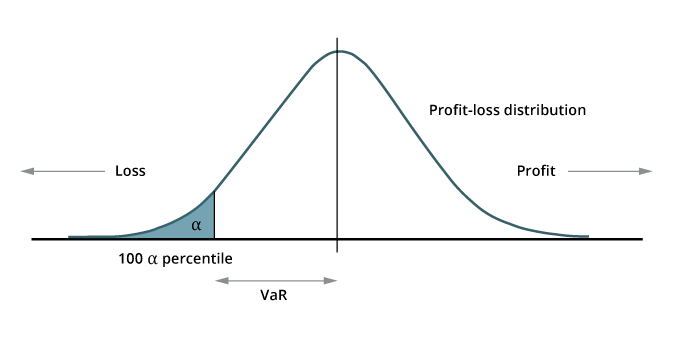

# CVaR (Expected shortfall)
a concept used in the field of financial risk measurement to evaluate the market risk or credit risk of a portfolio. The "expected shortfall at q% level" is the expected return on the portfolio in the worst q% of cases. ES is an alternative to value at risk that is more sensitive to the shape of the tail of the loss distribution.

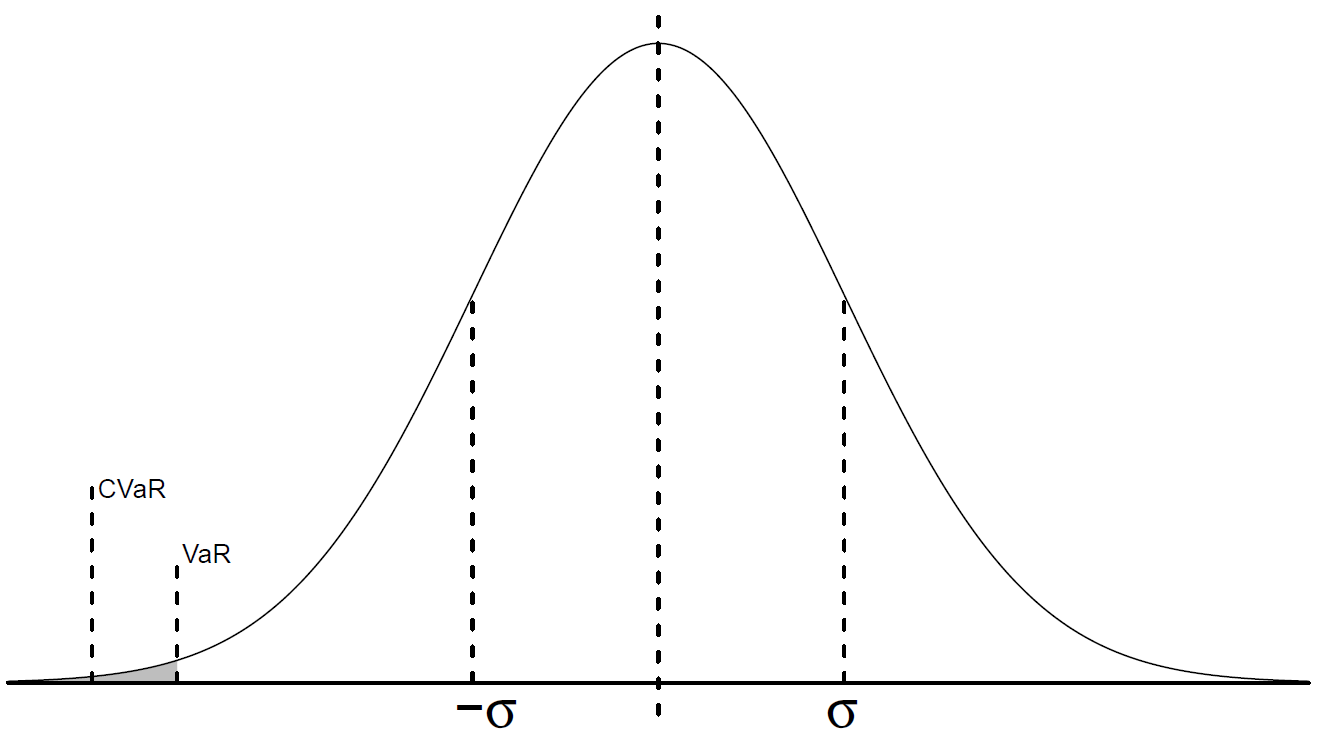

# Setup

In [32]:
import pandas as pd
import numpy as np
import random
from datetime import date, timedelta


import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 6))
plt.rc("savefig", dpi=90)
plt.rc("font", family="sans-serif")
plt.rc("font", size=10)

import pandas_datareader.data as web

In [12]:
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT",]
rf = .06

In [13]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-04-25


# Data

In [16]:
%%time
start_date = "2018-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE', "AAPL", "META", "TSLA", "^GSPC","MSFT",]
print(f"The number of stock to download are {len(tickers)}")
all_data = yf.download(tickers, start_date, yesterday)
price_data =  all_data["Adj Close"].copy() # pd.DataFrame({ticker: data['Adj Close'] for ticker, data in all_data.items()})
price_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1336 entries, 2018-01-02 00:00:00-05:00 to 2023-04-24 00:00:00-04:00
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1336 non-null   float64
 1   DIS     1336 non-null   float64
 2   KO      1336 non-null   float64
 3   MAT     1336 non-null   float64
 4   META    1336 non-null   float64
 5   MSFT    1336 non-null   float64
 6   NVDA    1336 non-null   float64
 7   PFE     1336 non-null   float64
 8   TSLA    1336 non-null   float64
 9   ^GSPC   1336 non-null   float64
dtypes: float64(10)
memory usage: 114.8 KB


In [17]:
price_data.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-02 00:00:00-05:00,40.888069,108.726051,38.548206,16.020000,181.419998,80.738167,49.326298,28.559784,21.368668,2695.810059
2018-01-03 00:00:00-05:00,40.880943,109.192848,38.463558,16.139999,184.669998,81.113899,52.572651,28.771395,21.150000,2713.060059
2018-01-04 00:00:00-05:00,41.070835,109.144234,39.005306,15.910000,184.330002,81.827820,52.849766,28.834087,20.974667,2723.989990
2018-01-05 00:00:00-05:00,41.538445,108.551003,38.996834,16.260000,186.850006,82.842339,53.297634,28.888950,21.105333,2743.149902
2018-01-08 00:00:00-05:00,41.384155,106.994980,38.937580,15.810000,188.279999,82.926895,54.930706,28.567616,22.427334,2747.709961


In [18]:
df_log = np.log(price_data.pct_change().dropna() +1)
df_log.head()

,AAPL,DIS,KO,MAT,META,MSFT,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2018-01-03 00:00:00-05:00,-0.000174,0.004284,-0.002198,0.007463,0.017756,0.004643,0.063739,0.007382,-0.010286,0.006378
2018-01-04 00:00:00-05:00,0.004634,-0.000445,0.013986,-0.014353,-0.001843,0.008763,0.005257,0.002177,-0.008325,0.004021
2018-01-05 00:00:00-05:00,0.011321,-0.005450,-0.000217,0.021760,0.013579,0.012322,0.008439,0.001901,0.006210,0.007009
2018-01-08 00:00:00-05:00,-0.003721,-0.014438,-0.001521,-0.028065,0.007624,0.001020,0.030181,-0.011185,0.060755,0.001661
2018-01-09 00:00:00-05:00,-0.000115,-0.000727,0.004987,0.000632,-0.002180,-0.000680,-0.000270,-0.001098,-0.008118,0.001302


# Semi-Deviation

Semi-deviation is an alternative measurement to standard deviation or variance. However, unlike those measures, semi-deviation looks only at negative price fluctuations. Thus, semi-deviation is most often used to evaluate the downside risk of an investment.

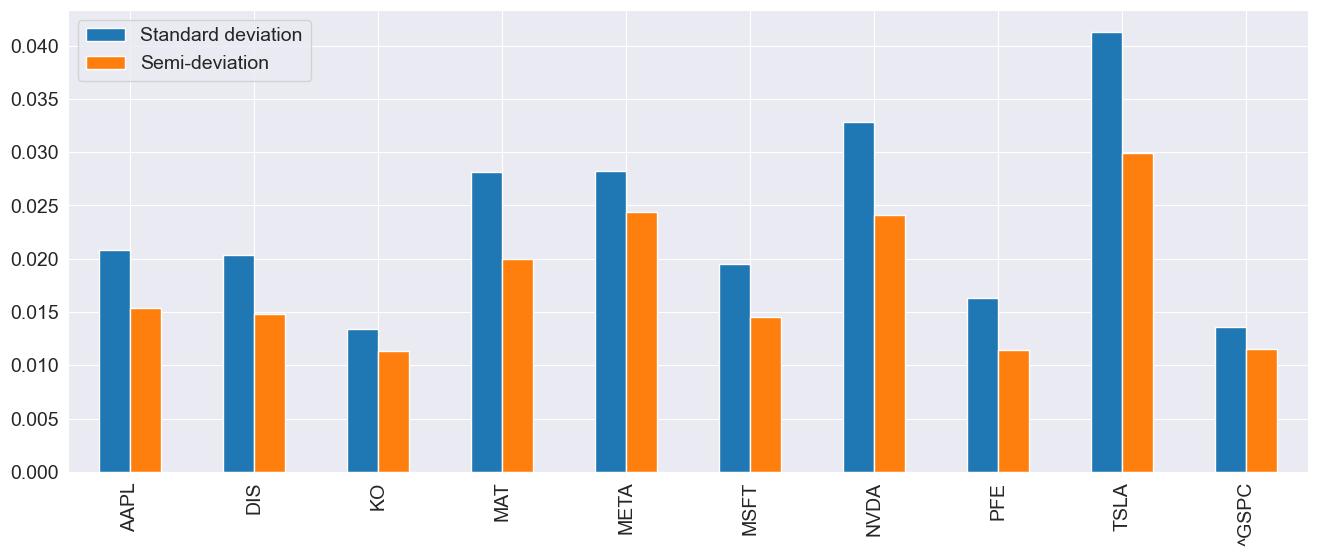

In [19]:
pd.concat(
    [
        df_log.std(),
        df_log[
          df_log < 0
        ].std(),
    ],axis=1
).rename(
    columns={
        0:'Standard deviation',
        1:'Semi-deviation'
    }
).plot(kind='bar');

# VaR and CVaR
- Historic VaR
- Parametric Gaussian VaR
- Modified VaR (Cornish-Fisher)

## Historic

### VaR

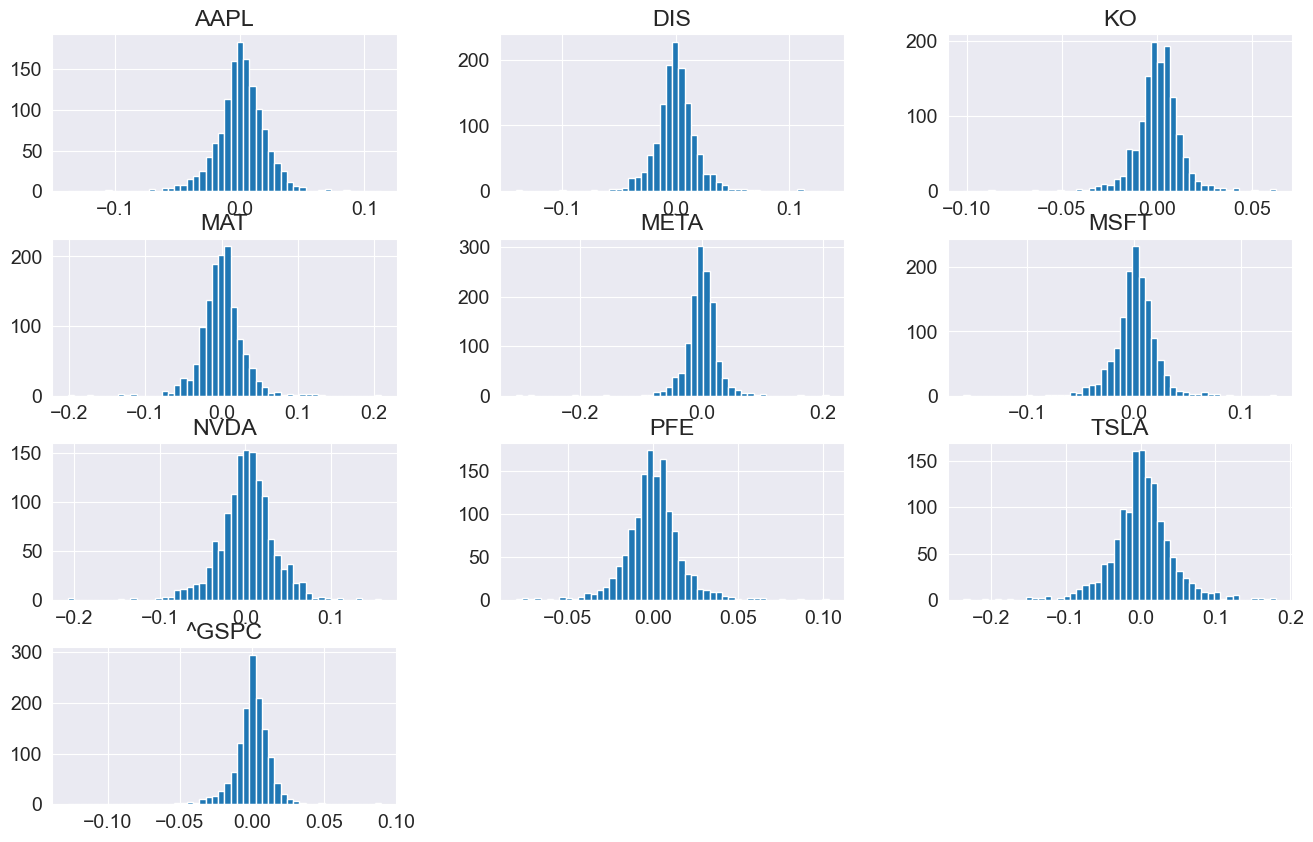

In [29]:
df_log.hist(
    bins=50,
    figsize=(16,10)
);

In [30]:
def historic_var(df, level_confidence):
    return (df.agg(np.percentile, q=100-level_confidence) * -1).sort_values()

historic_var(df_log, 95)

KO       0.018338
^GSPC    0.020994
PFE      0.023883
MSFT     0.029987
DIS      0.030347
AAPL     0.032348
META     0.041056
MAT      0.042167
NVDA     0.052326
TSLA     0.065411
dtype: float64

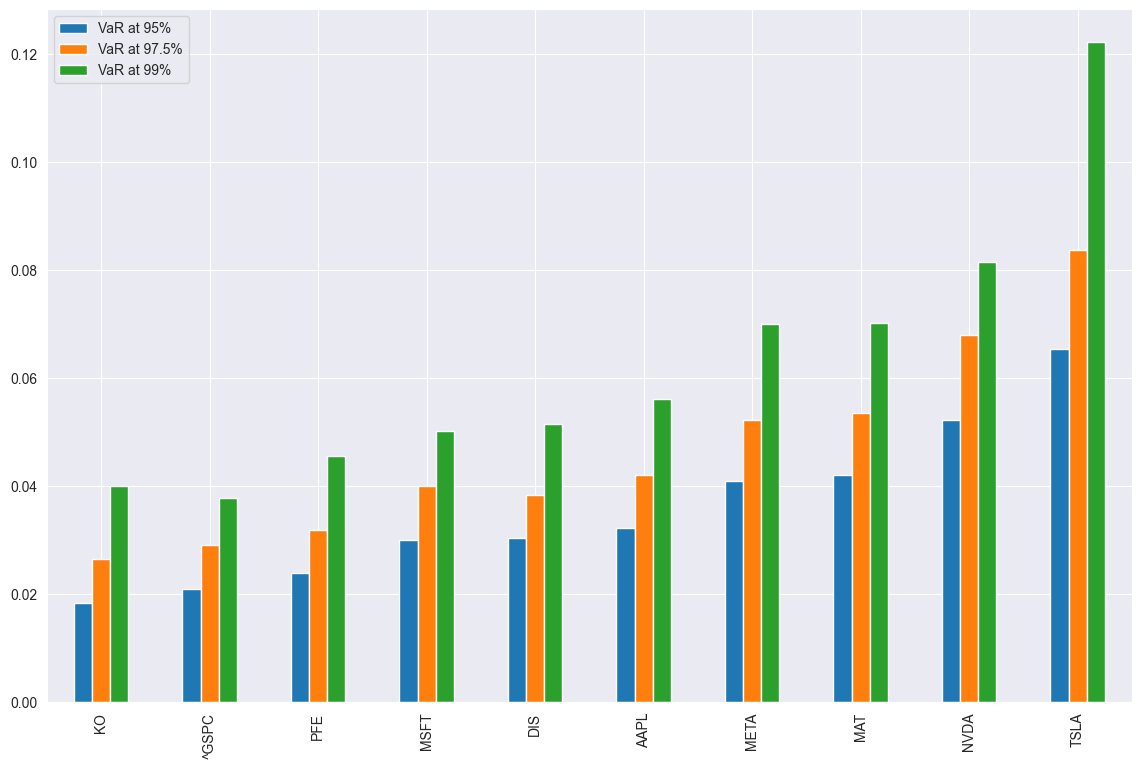

In [35]:
df_historic_var = pd.concat(
    [
        historic_var(df_log, 95),
        historic_var(df_log, 97.5),
        historic_var(df_log, 99)
    ],axis=1
).rename(
    columns={
        0:'VaR at 95%',
        1:'VaR at 97.5%',
        2:'VaR at 99%'        
    }
)

df_historic_var.plot(
    figsize=(14,9),
    kind='bar', 
    legend=True
);

In [36]:
df_historic_var

,VaR at 95%,VaR at 97.5%,VaR at 99%
KO,0.018338,0.026525,0.039995
^GSPC,0.020994,0.029195,0.037817
PFE,0.023883,0.031994,0.045637
MSFT,0.029987,0.040055,0.050248
DIS,0.030347,0.038392,0.051480
AAPL,0.032348,0.042127,0.056214
META,0.041056,0.052324,0.070116
MAT,0.042167,0.053593,0.070188
NVDA,0.052326,0.068078,0.081581
TSLA,0.065411,0.083726,0.122222


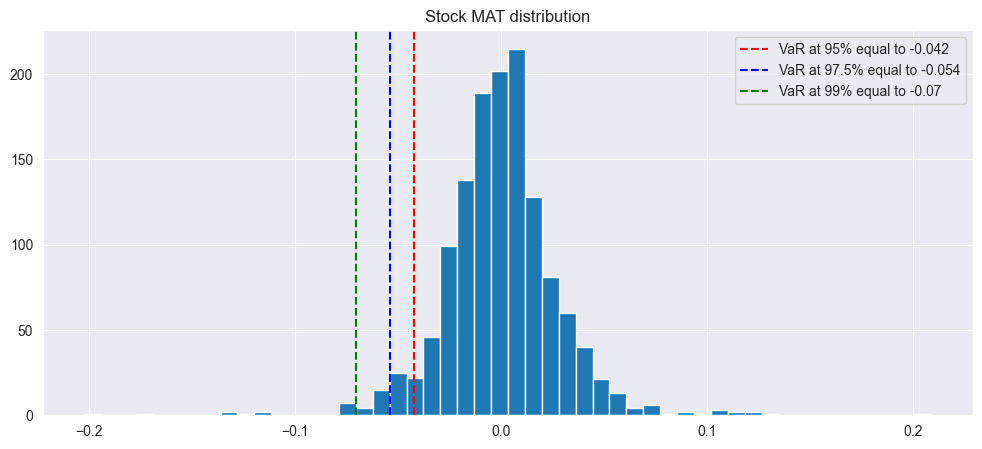

--------------------------------------------------


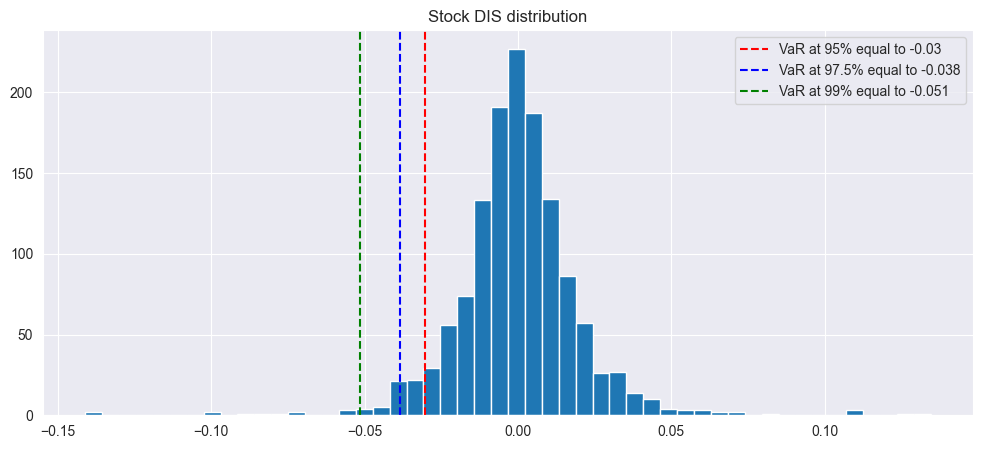

--------------------------------------------------


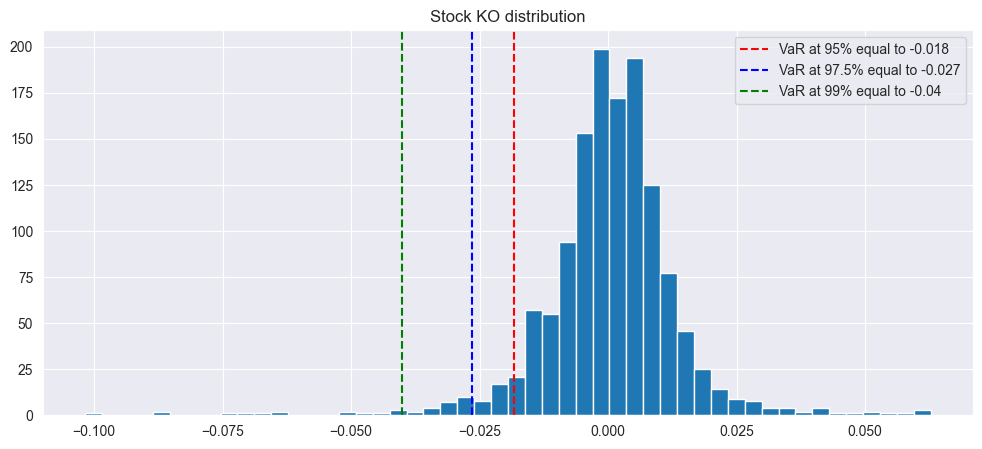

--------------------------------------------------


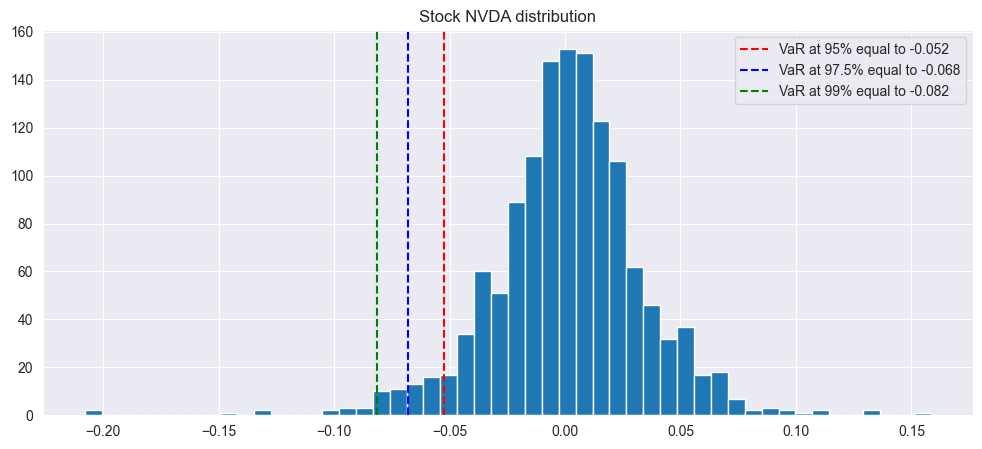

--------------------------------------------------


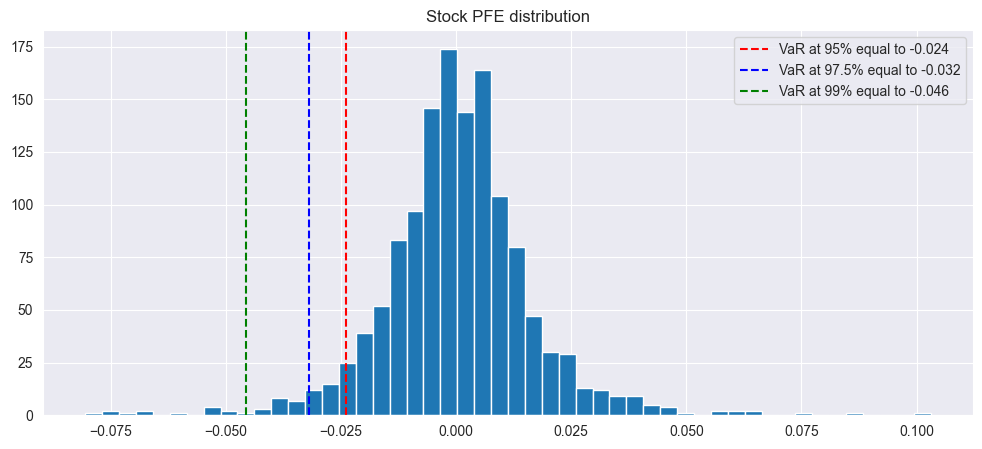

--------------------------------------------------


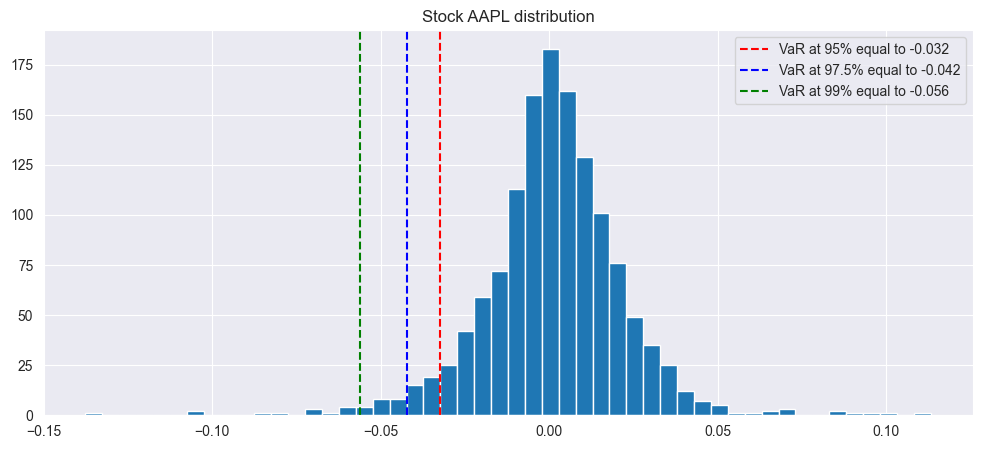

--------------------------------------------------


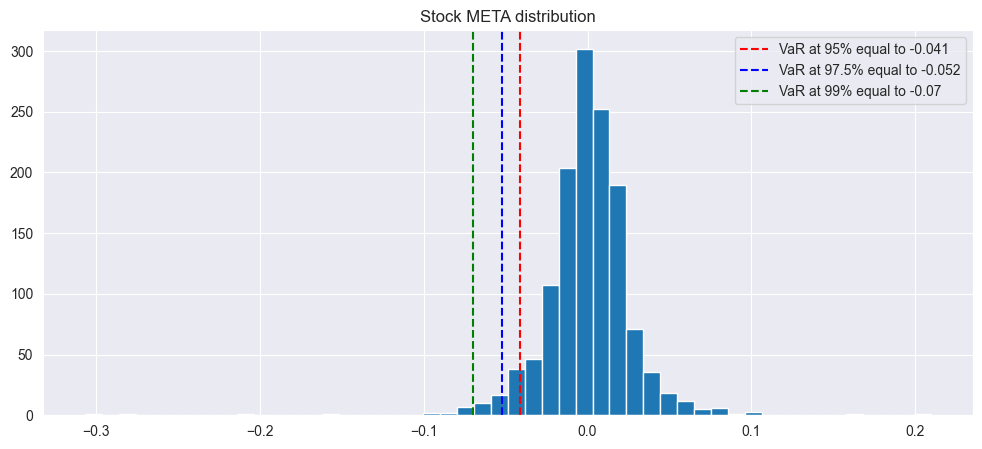

--------------------------------------------------


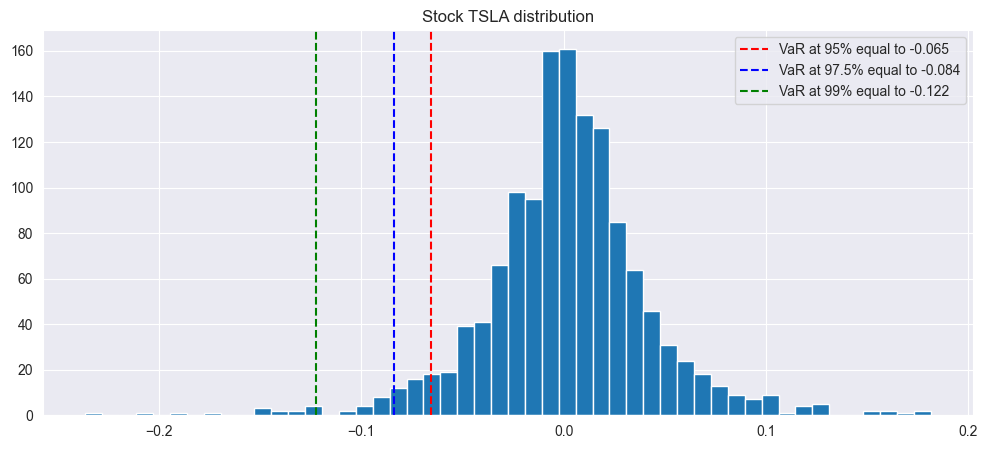

--------------------------------------------------


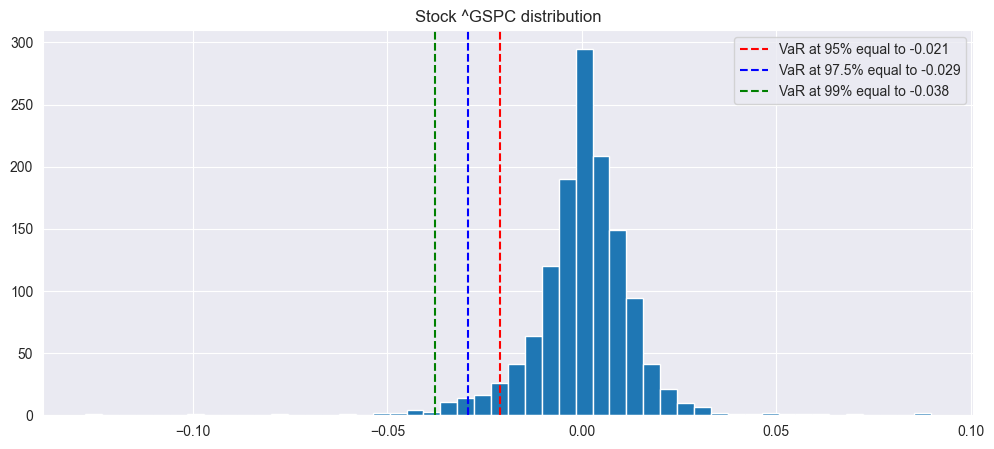

--------------------------------------------------


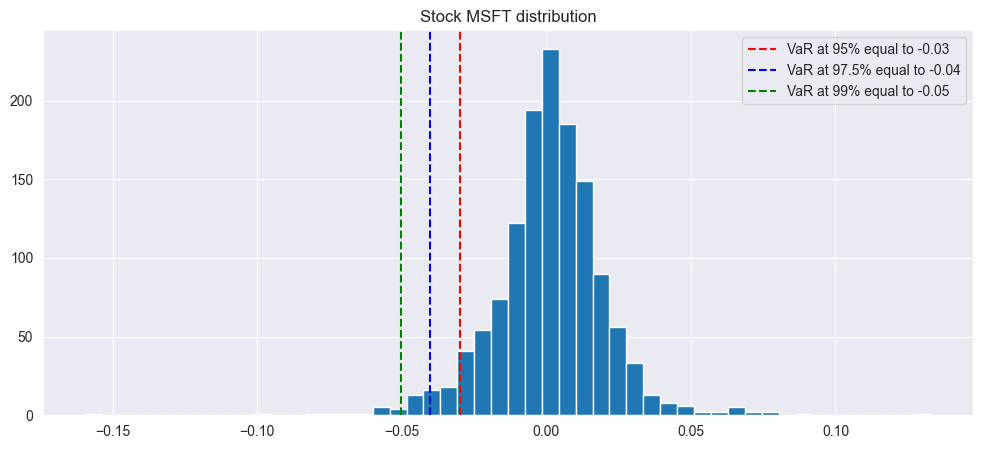

--------------------------------------------------


In [37]:
colors_to_plot = ['red',"blue","green"]
for ticker in tickers:
  df_log[ticker].hist(bins=50,figsize=(12,5));
  plt.title(f"Stock {ticker} distribution");
  for var_metric, color_plot in zip(df_historic_var.columns,colors_to_plot):
    value_to_plot = df_historic_var.loc[ticker,var_metric]
    plt.axvline(-value_to_plot, label=f"{var_metric} equal to {-round(value_to_plot, 3)}", linestyle='--', color=color_plot);
    plt.legend();
  plt.show();
  print(50*"-")


### CVaR

In [38]:
def historic_cvar(df, level_confidence):
  var_values = historic_var(df, level_confidence)
  tickers = []
  cvars = []
  lst_vars = []
  for ticker in df:
    var = var_values.loc[ticker]
    cvar = df[df[ticker]< -var][ticker].mean() * -1
    tickers.append(ticker)
    cvars.append(cvar)
    lst_vars.append(var)

  df_result = pd.DataFrame(
      {
          'stock':tickers,
          'VaR':lst_vars,
          'CVaR':cvars
      }
  )
  return df_result

cvar_95_data = historic_cvar(df_log, 95)
cvar_95_data

,stock,VaR,CVaR
0,AAPL,0.032348,0.048273
1,DIS,0.030347,0.046327
2,KO,0.018338,0.033634
3,MAT,0.042167,0.063464
4,META,0.041056,0.066787
5,MSFT,0.029987,0.044603
6,NVDA,0.052326,0.076514
7,PFE,0.023883,0.037461
8,TSLA,0.065411,0.095980
9,^GSPC,0.020994,0.033999


In [14]:
cvar_95_data.loc[cvar_95_data.stock == 'KO', "VaR"].iloc[0]

0.017663484202167255

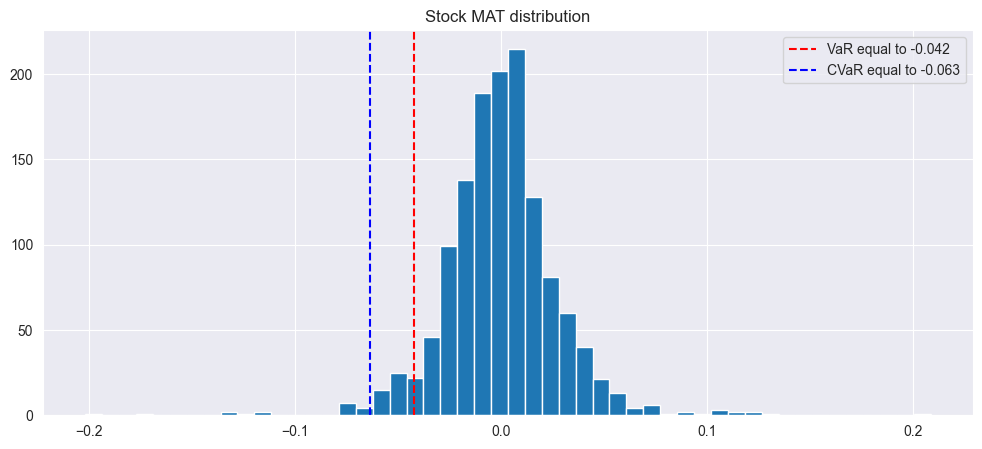

--------------------------------------------------


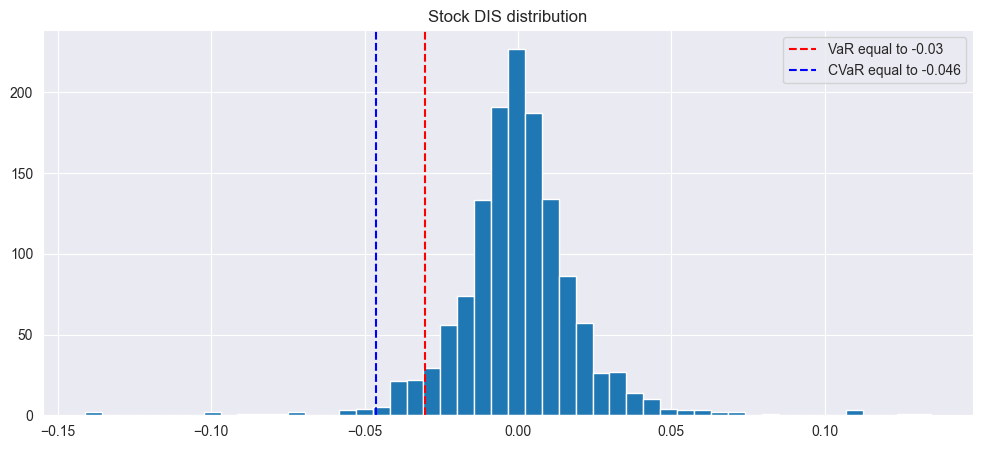

--------------------------------------------------


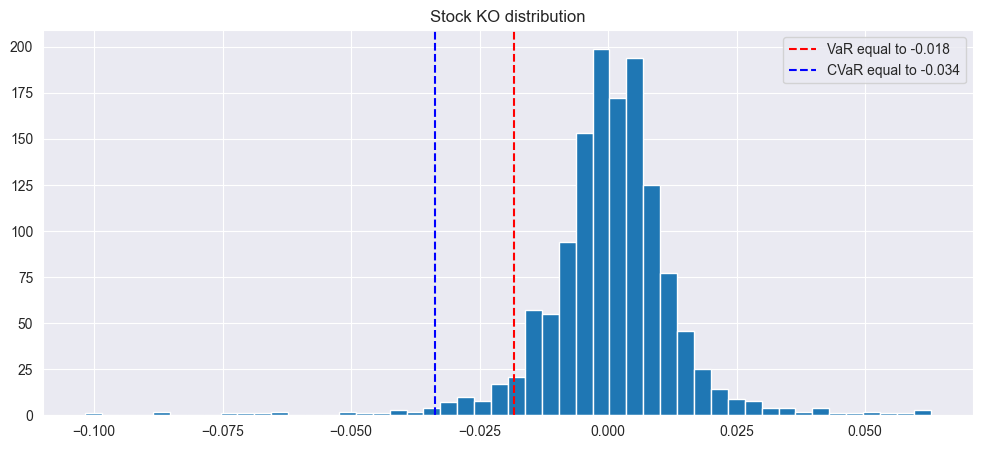

--------------------------------------------------


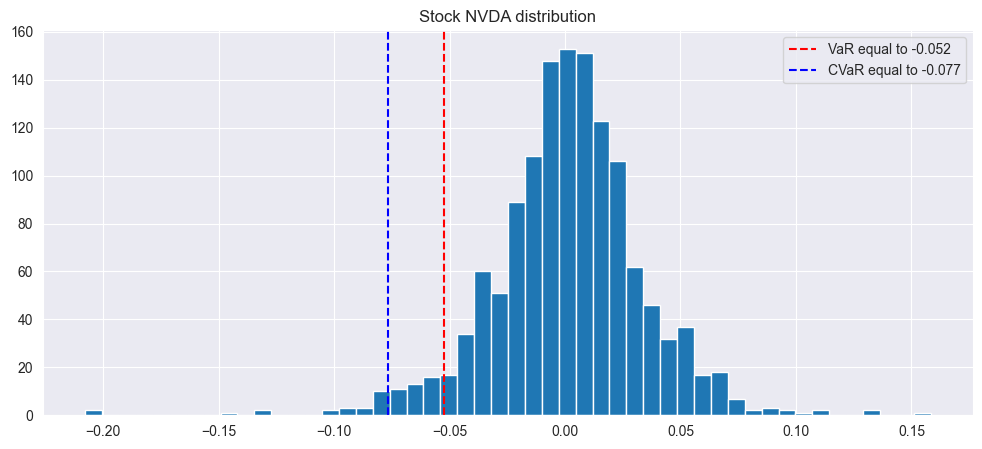

--------------------------------------------------


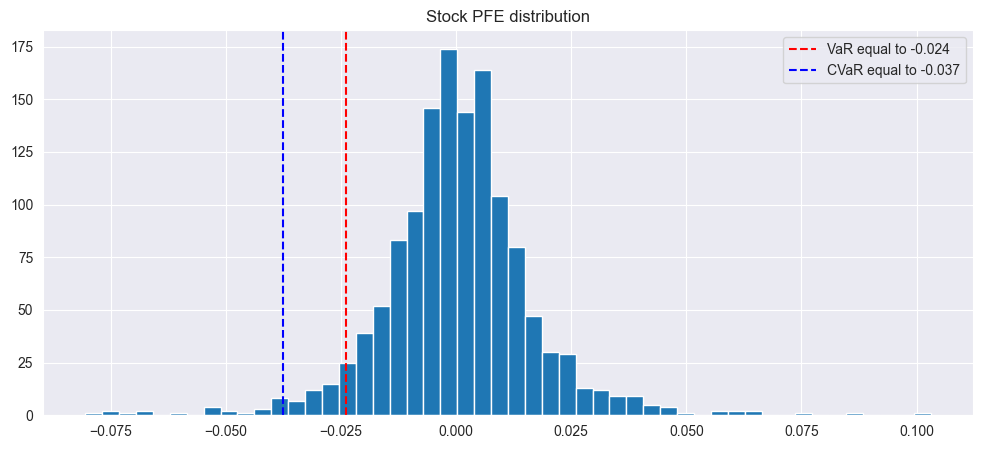

--------------------------------------------------


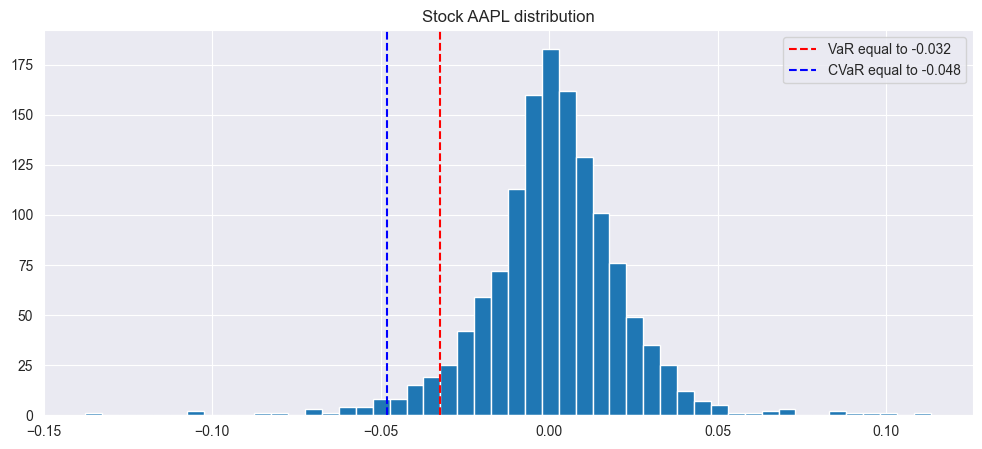

--------------------------------------------------


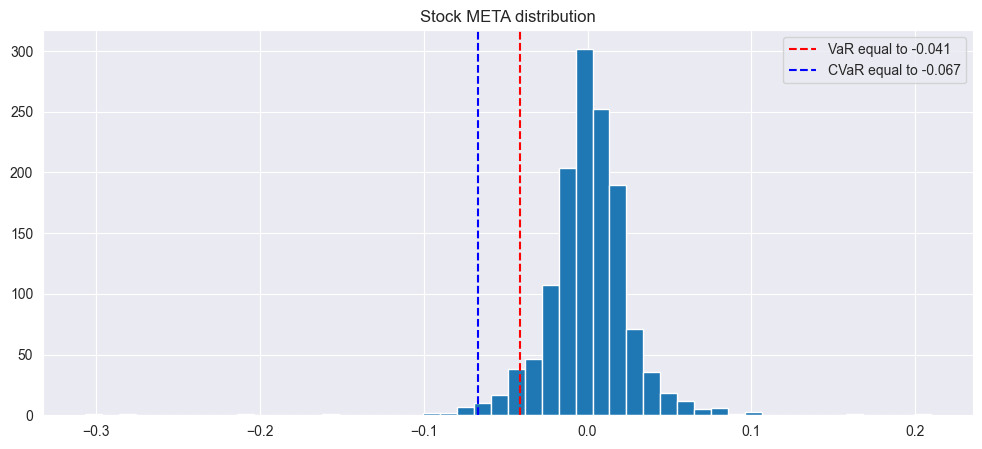

--------------------------------------------------


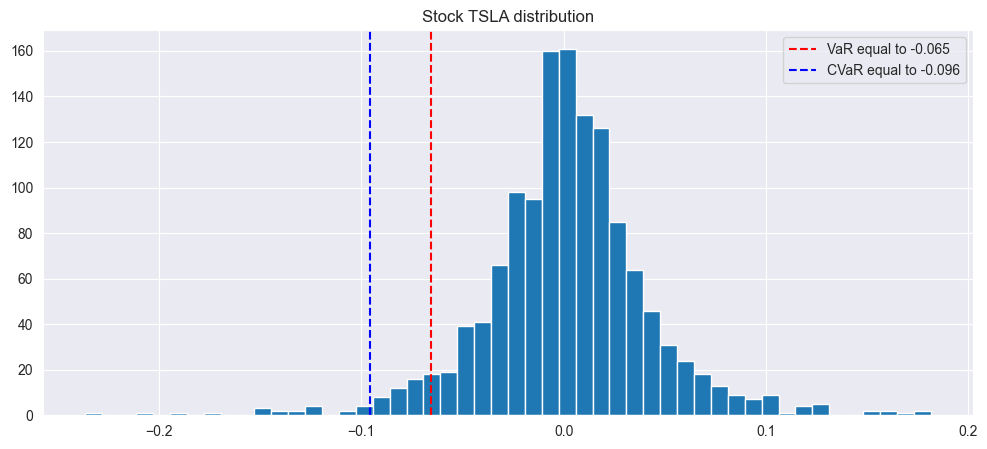

--------------------------------------------------


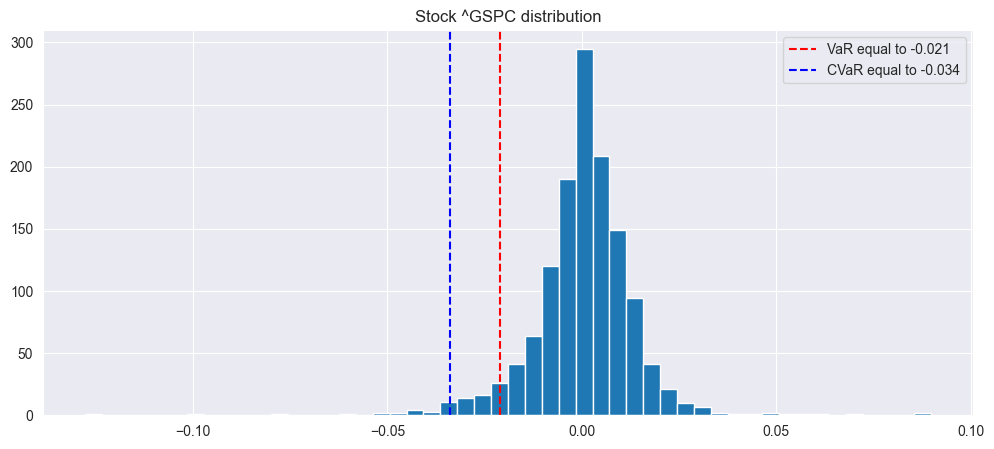

--------------------------------------------------


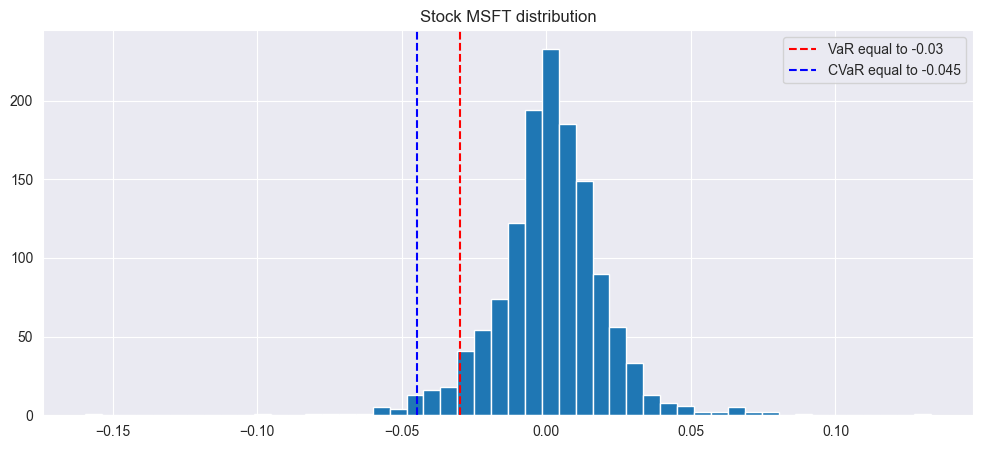

--------------------------------------------------


In [39]:
for ticker in tickers:
  df_log[ticker].hist(bins=50,figsize=(12,5));
  plt.title(f"Stock {ticker} distribution");
  for var_metric, color_plot in [("VaR",'red'),("CVaR","blue")]:
    value_to_plot = cvar_95_data.loc[cvar_95_data['stock'] == ticker,var_metric].iloc[0]
    plt.axvline(-value_to_plot, label=f"{var_metric} equal to {-round(value_to_plot, 3)}", linestyle='--', color=color_plot);
    plt.legend();
  plt.show();
  print(50*"-")

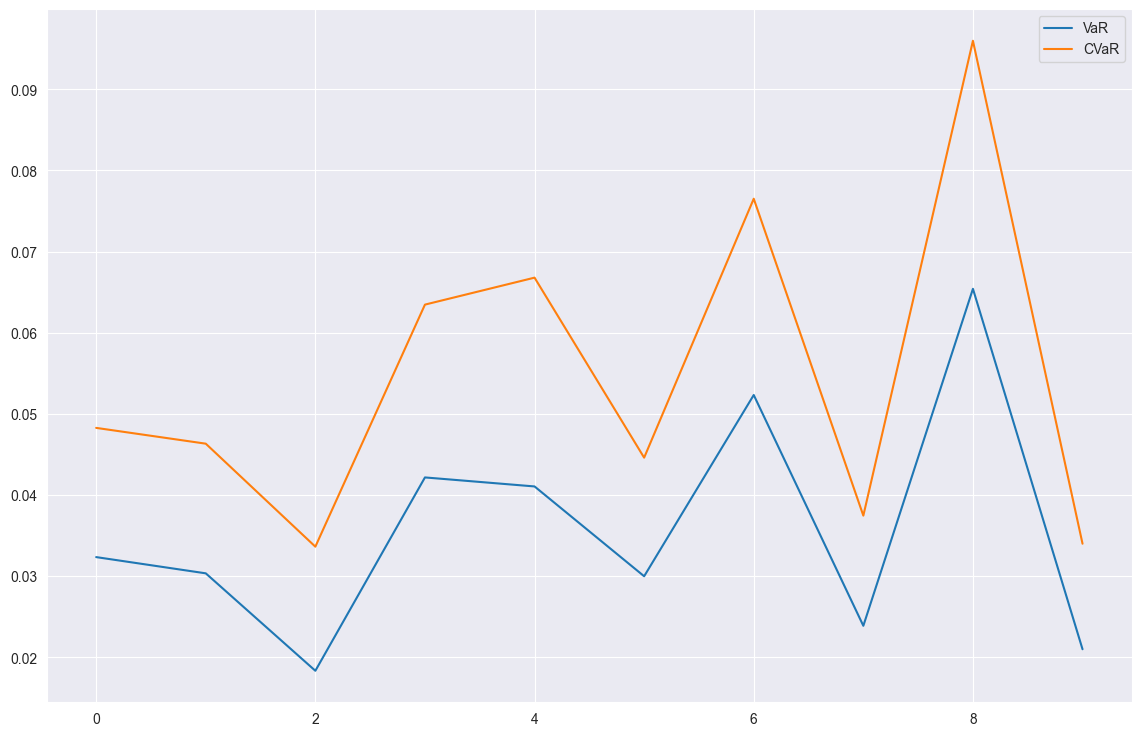

In [40]:
cvar_95_data.plot(figsize=(14,9));

## Parametric Gaussian VaR

It is a risk management technique for calculating the VaR of a portfolio of assets or asset that first identifies the mean, or expected value, and standard deviation of an investment portfolio or asset. The parametric method looks at the price movements of investments over a look-back period and uses probability theory to compute a portfolio's maximum loss. The variance-covariance method for the value at risk calculates the standard deviation of price movements of an investment or security. Assuming stock price returns and volatility follow a normal distribution, the maximum loss within the specified confidence level is calculated.

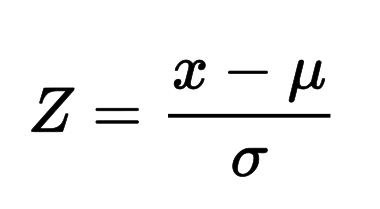

In [43]:
from scipy.stats import norm
def parametric_var(
    df:pd.DataFrame, 
    level_confidence:float=95
) -> pd.Series:
  """
  Get parametric var from log-returns pd.DataFrame
  Parameters 
  ----------
  df
  level_confidence
  """
  level = (100-level_confidence) / 100
  z = norm.ppf(level)
  return -(z*df.std(ddof=0) + df.mean())


parametric_var(df_log)

AAPL     0.033139
DIS      0.033487
KO       0.021689
MAT      0.046206
META     0.046247
MSFT     0.031089
NVDA     0.052662
PFE      0.026536
TSLA     0.066357
^GSPC    0.022089
dtype: float64

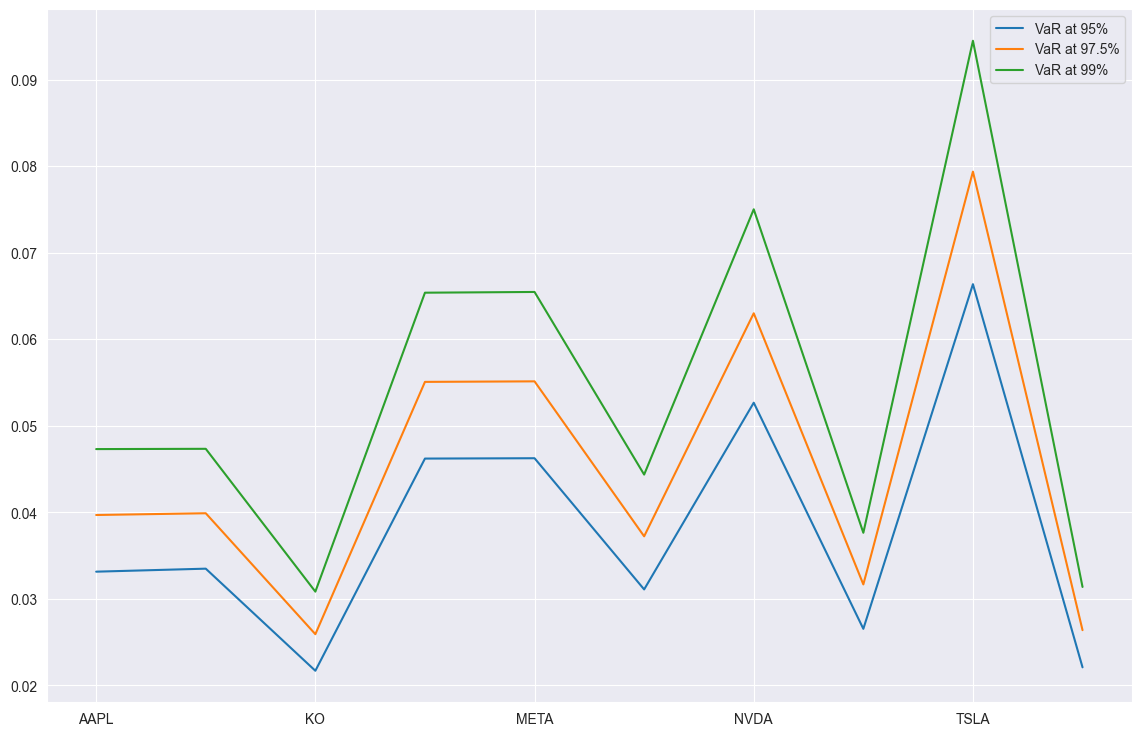

In [44]:
df_parametric_var = pd.concat(
    [
        parametric_var(df_log, 95),
        parametric_var(df_log, 97.5),
        parametric_var(df_log, 99)
    ],axis=1
).rename(
    columns={
        0:'VaR at 95%',
        1:'VaR at 97.5%',
        2:'VaR at 99%'        
    }
)

df_parametric_var.plot(figsize=(14,9));

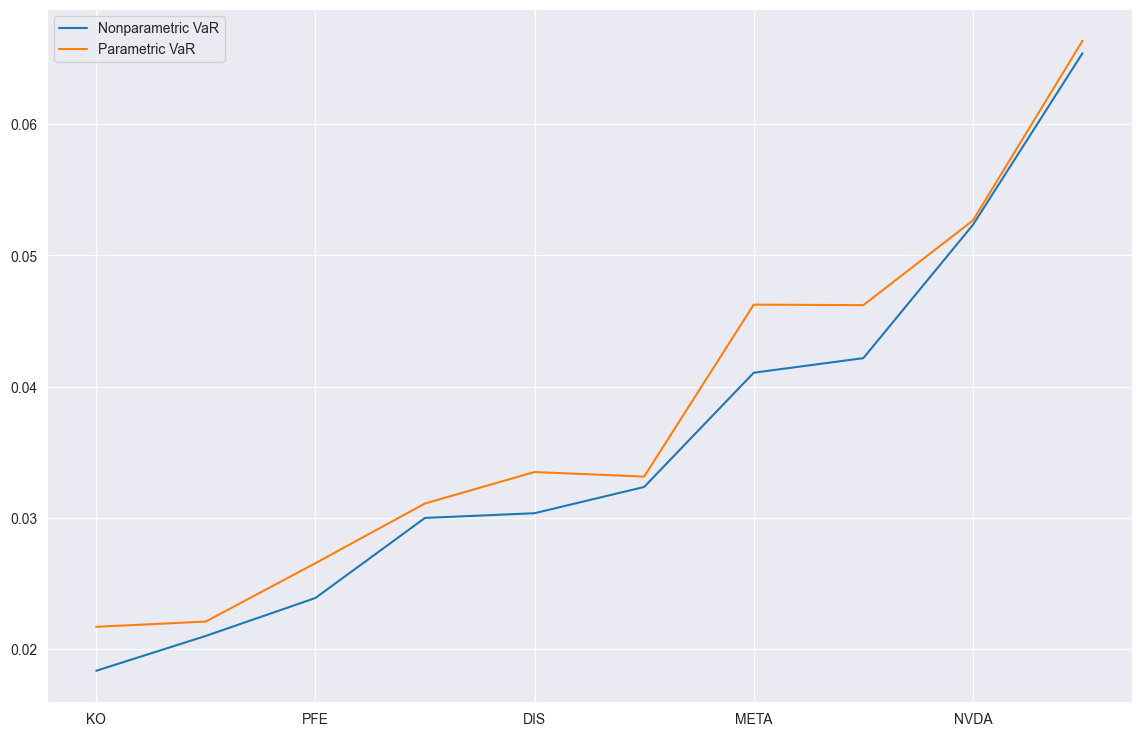

In [45]:
df_comp_vars = pd.concat(
    [
        historic_var(df_log, 95),
        parametric_var(df_log, 95),
        
    ],axis=1
).rename(
    columns={
        0:'Nonparametric VaR',
        1:'Parametric VaR'
    }
)

df_comp_vars.plot(figsize=(14,9));

### Skewness

$$ S(R) = \frac{E[ (R-E(R))^3 ]}{\sigma_R^3} $$

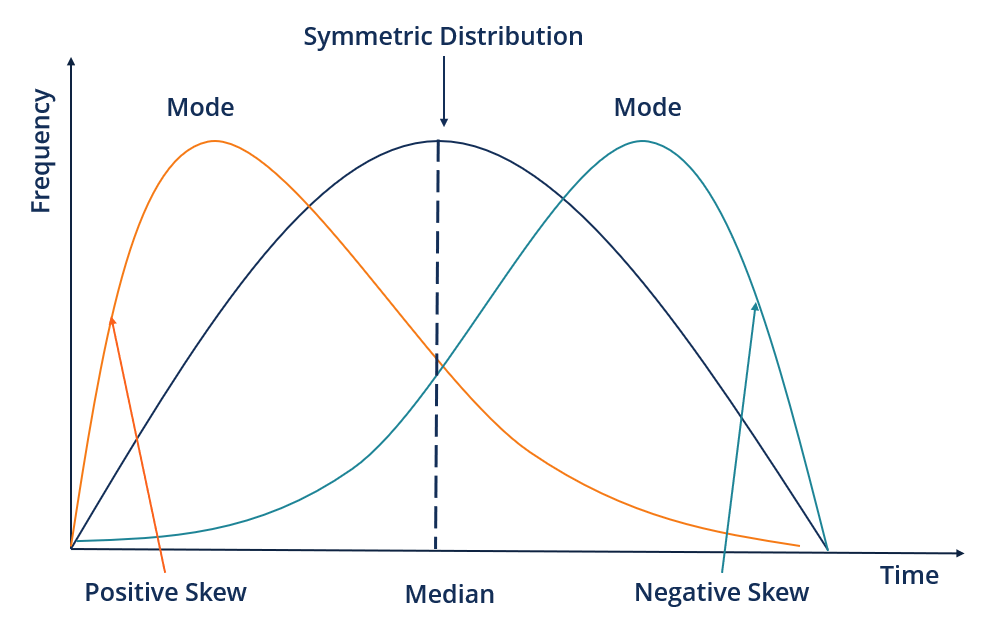

In [46]:
def skewness(r):
  r_minus_mean = r-r.mean()
  sigma_r = r.std(ddof=0)
  exp = (r_minus_mean**3).mean()
  return exp/sigma_r**3

In [47]:
skewness(df_log).sort_values()

META    -1.682919
KO      -0.938716
^GSPC   -0.784912
NVDA    -0.423221
MSFT    -0.260413
AAPL    -0.238225
TSLA    -0.152910
MAT     -0.005519
PFE      0.086691
DIS      0.091387
dtype: float64

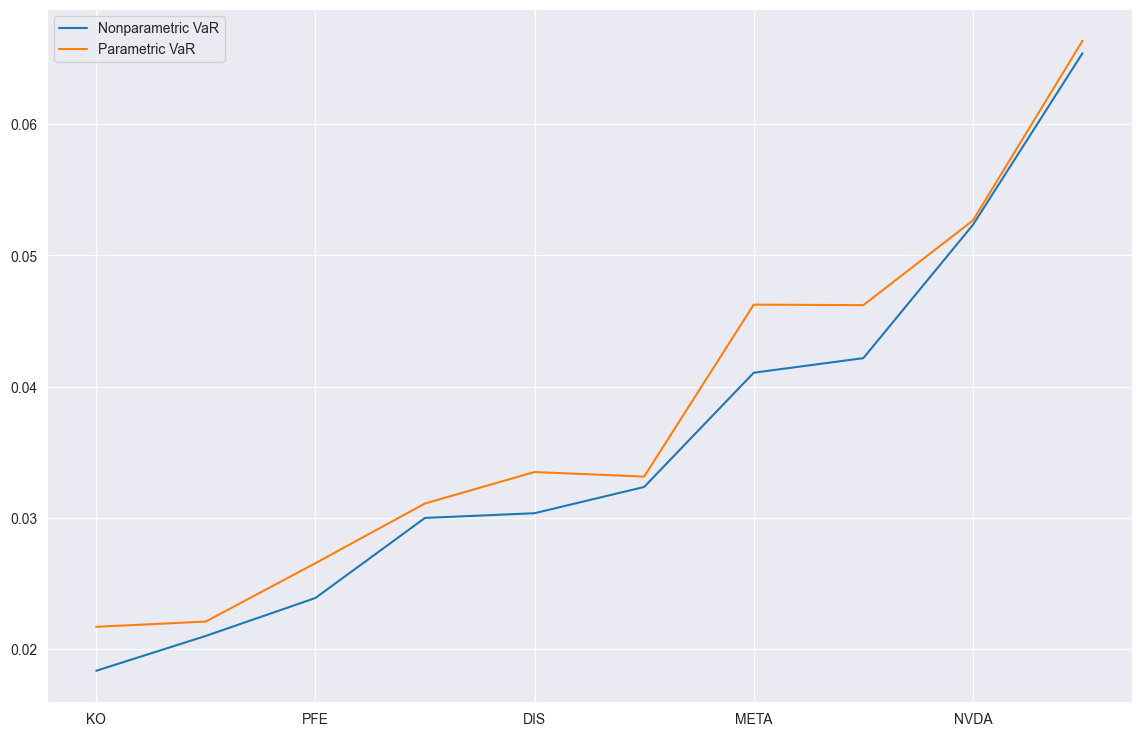

In [48]:
df_comp_vars = pd.concat(
    [
        historic_var(df_log, 95),
        parametric_var(df_log, 95),
        
    ],axis=1
).rename(
    columns={
        0:'Nonparametric VaR',
        1:'Parametric VaR'
    }
)

df_comp_vars.plot(figsize=(14,9));

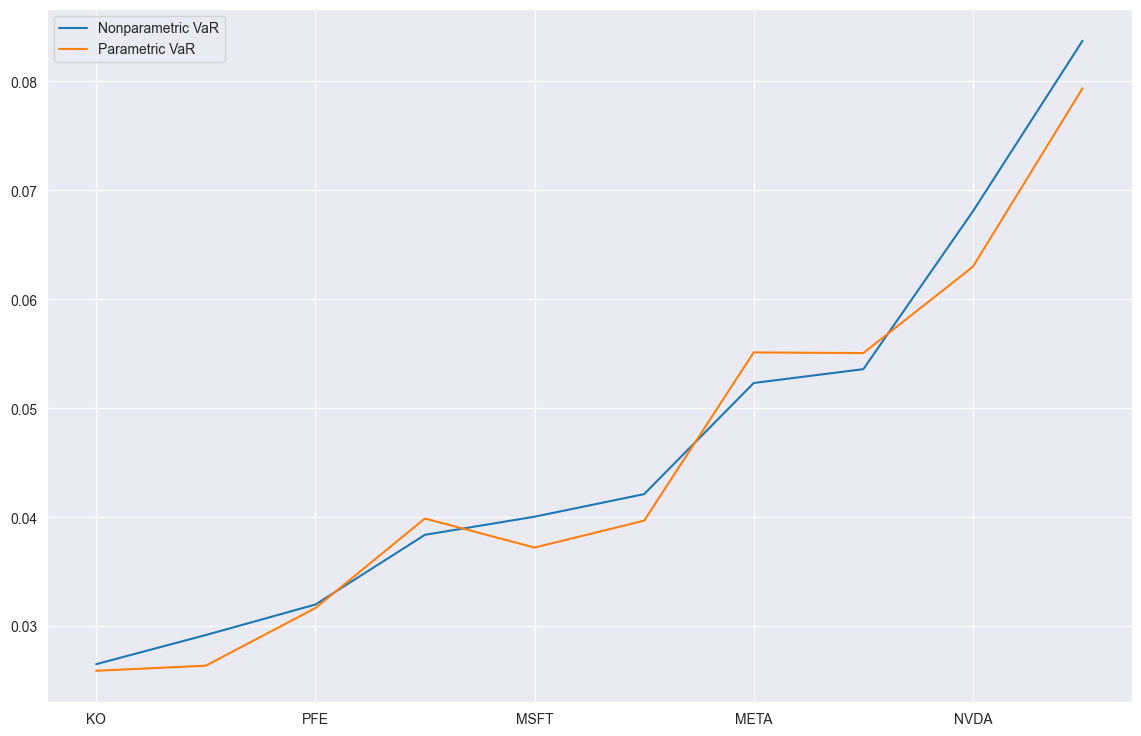

In [55]:
df_comp_vars = pd.concat(
    [
        historic_var(df_log, 97.5),
        parametric_var(df_log, 97.5),
        
    ],axis=1
).rename(
    columns={
        0:'Nonparametric VaR',
        1:'Parametric VaR'
    }
)

df_comp_vars.plot(figsize=(14,9));

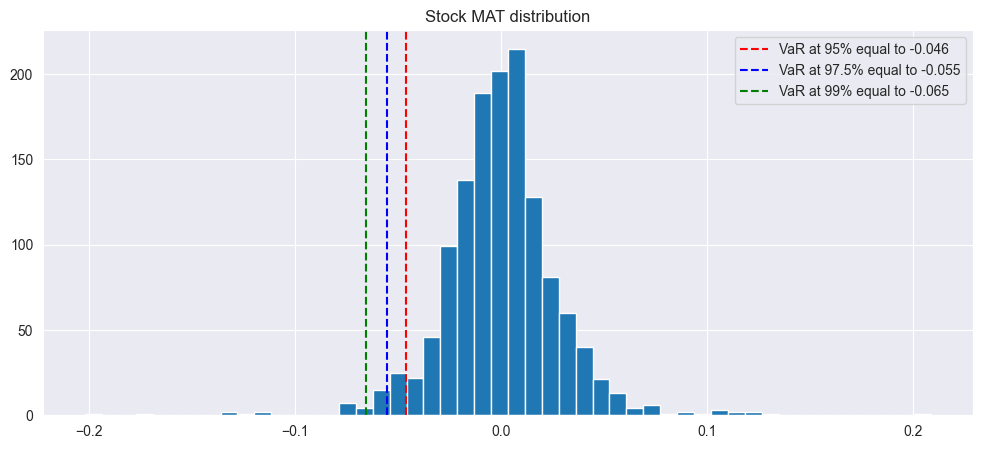

--------------------------------------------------


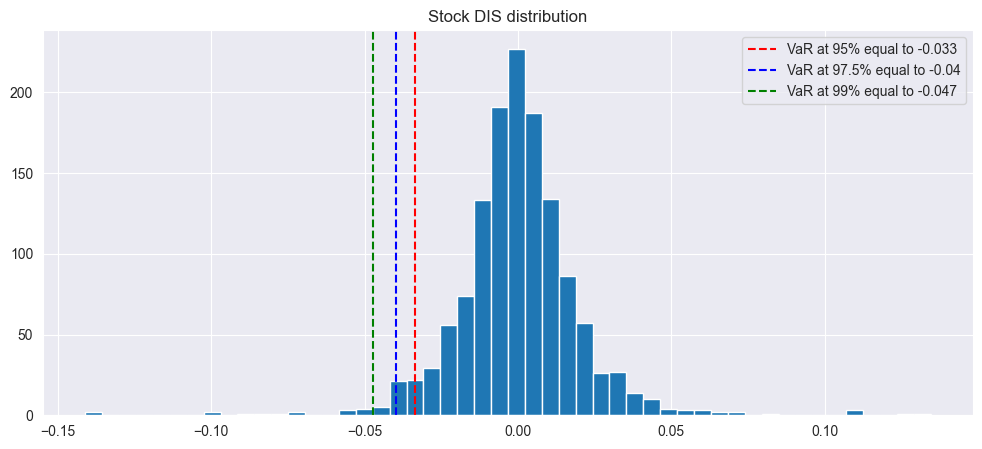

--------------------------------------------------


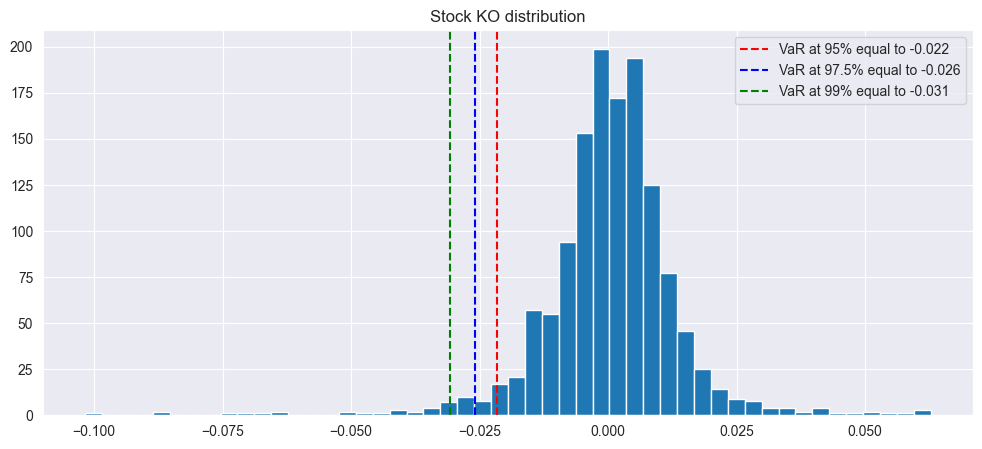

--------------------------------------------------


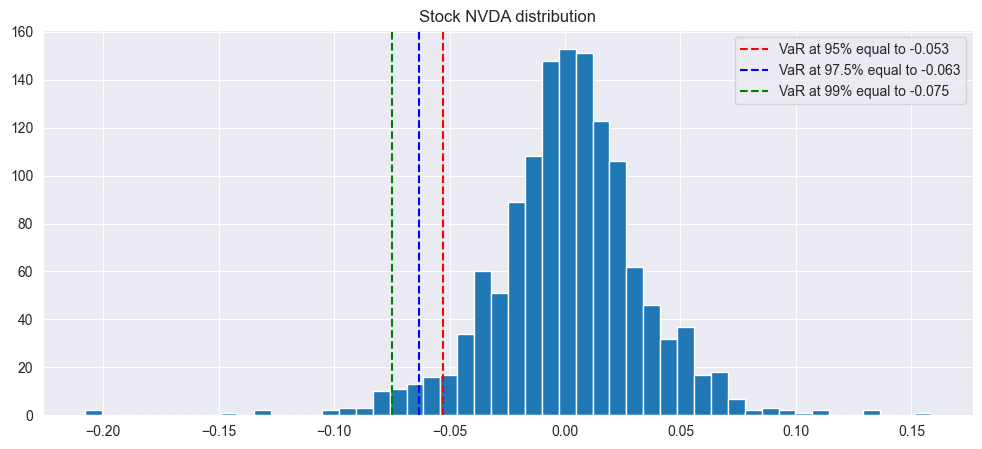

--------------------------------------------------


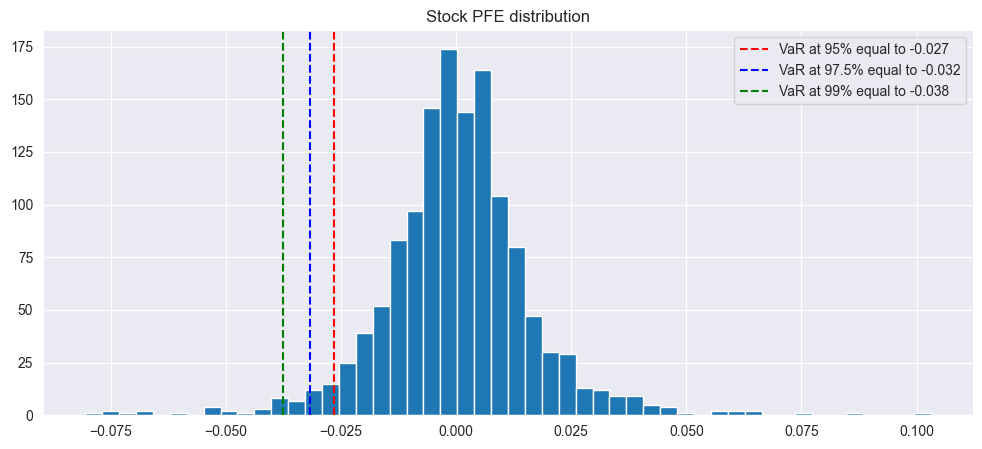

--------------------------------------------------


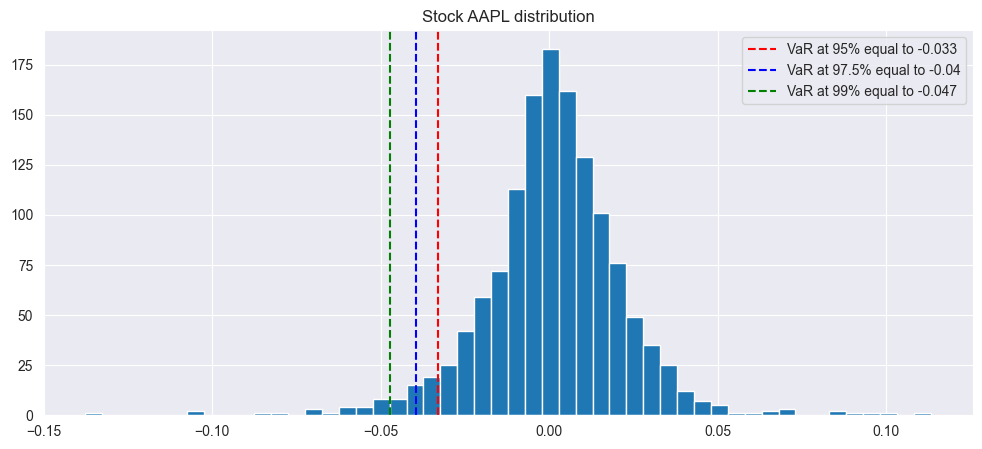

--------------------------------------------------


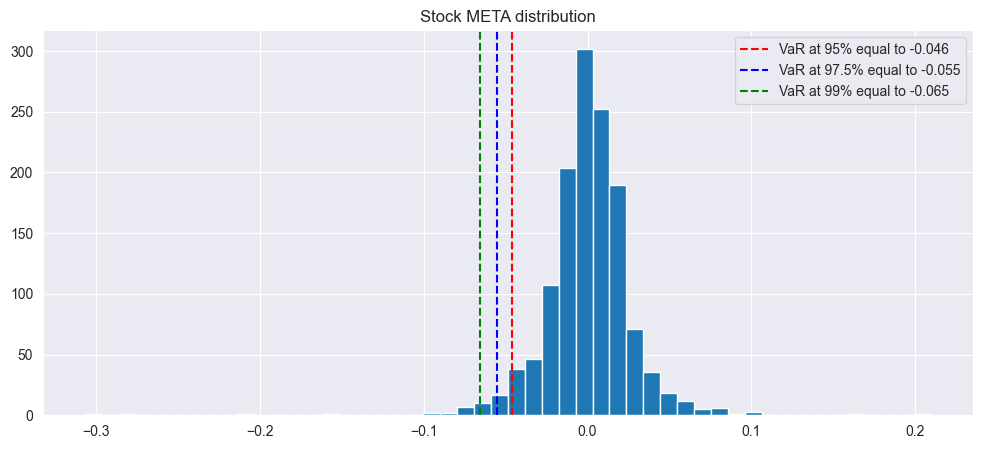

--------------------------------------------------


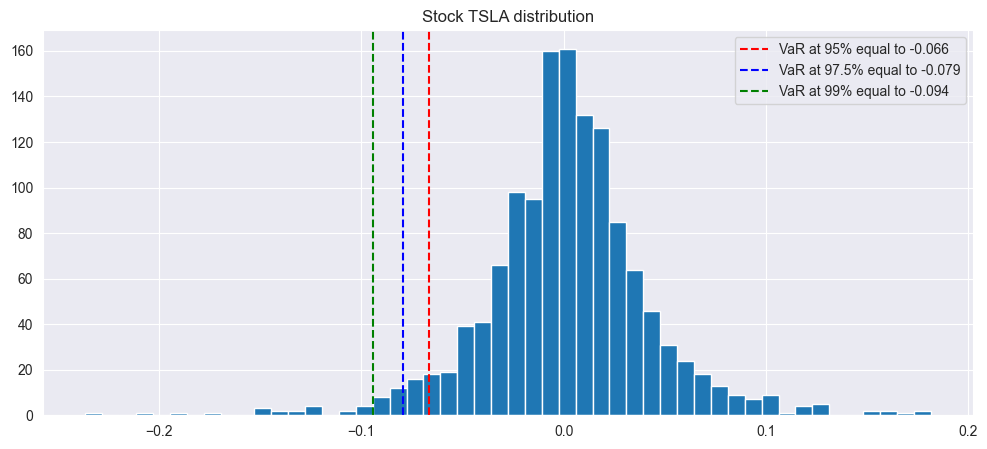

--------------------------------------------------


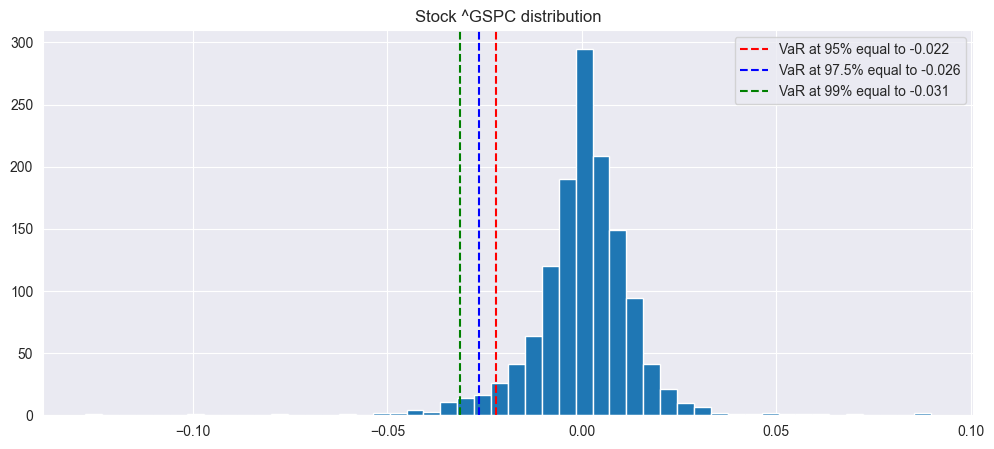

--------------------------------------------------


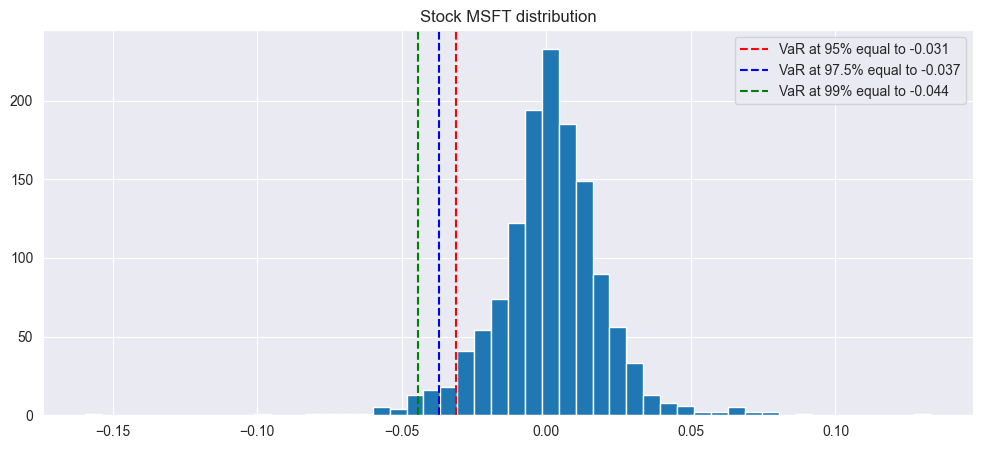

--------------------------------------------------


In [52]:
colors_to_plot = ['red',"blue","green"]
for ticker in tickers:
  df_log[ticker].hist(bins=50,figsize=(12,5));
  plt.title(f"Stock {ticker} distribution");
  for var_metric, color_plot in zip(df_parametric_var.columns,colors_to_plot):
    value_to_plot = df_parametric_var.loc[ticker,var_metric]
    plt.axvline(-value_to_plot, label=f"{var_metric} equal to {-round(value_to_plot, 3)}", linestyle='--', color=color_plot);
    plt.legend();
  plt.show();
  print(50*"-")


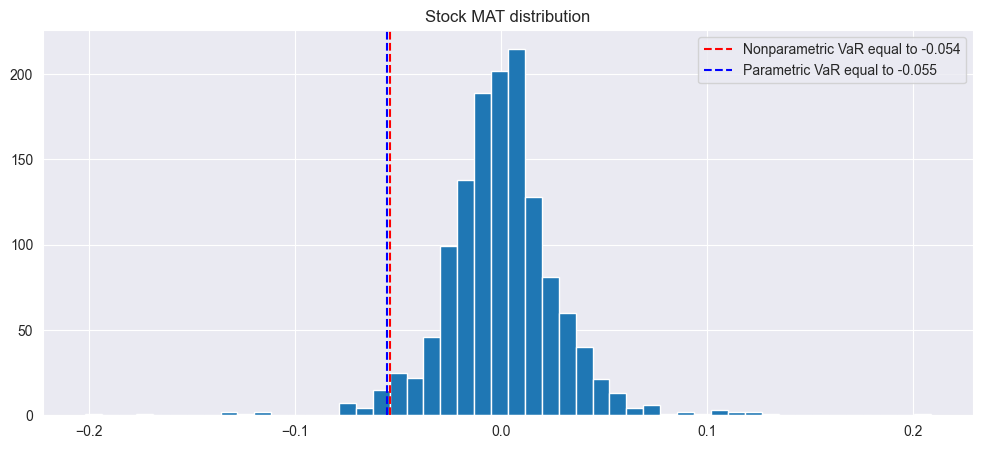

--------------------------------------------------


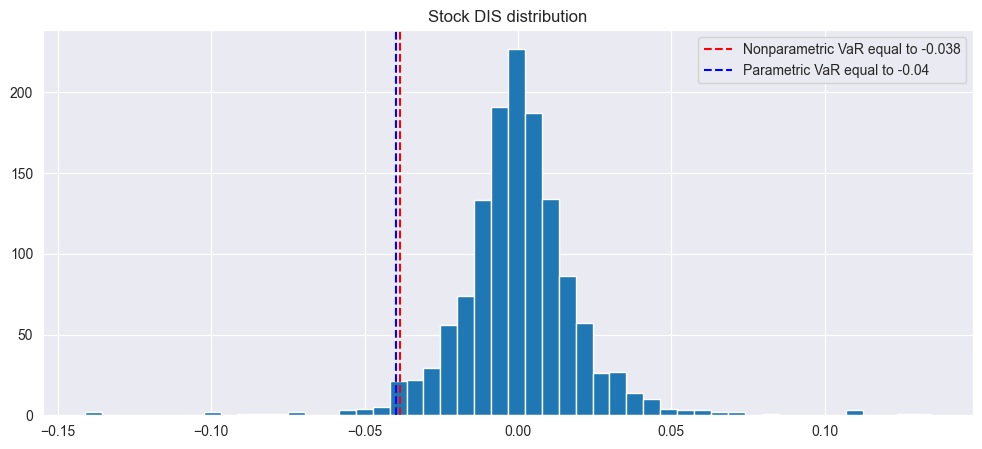

--------------------------------------------------


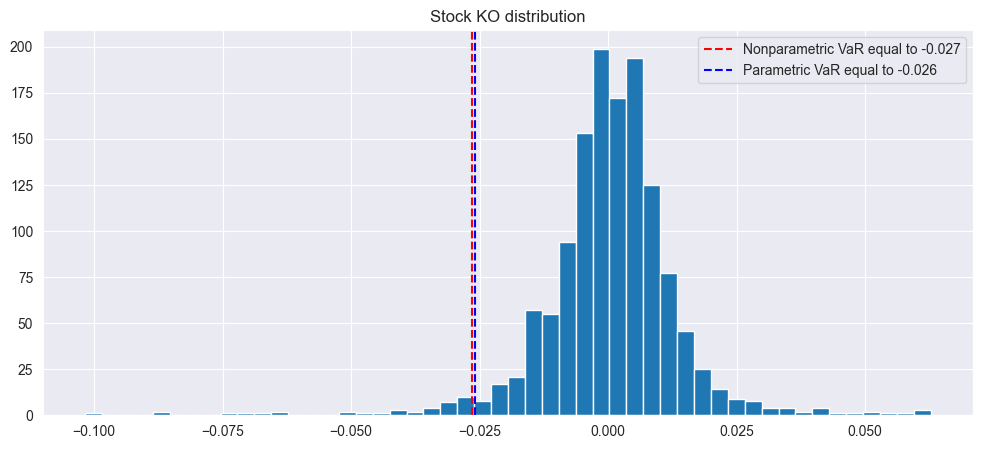

--------------------------------------------------


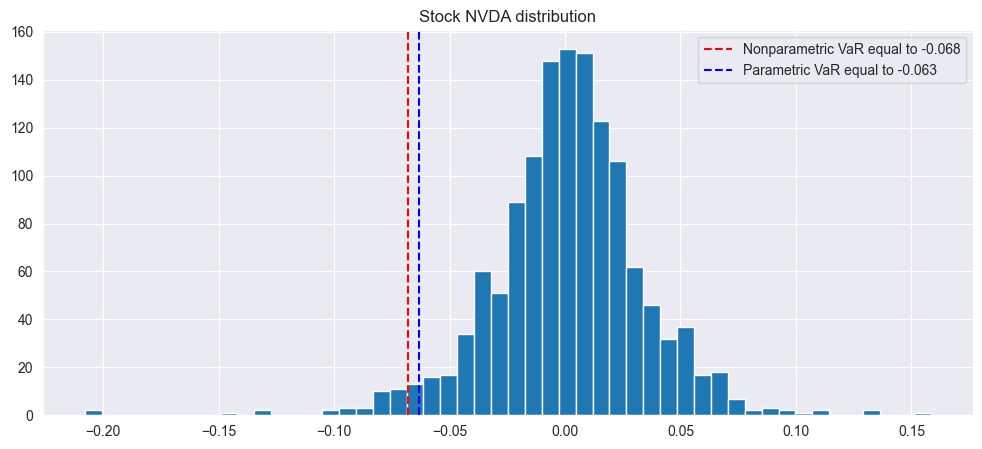

--------------------------------------------------


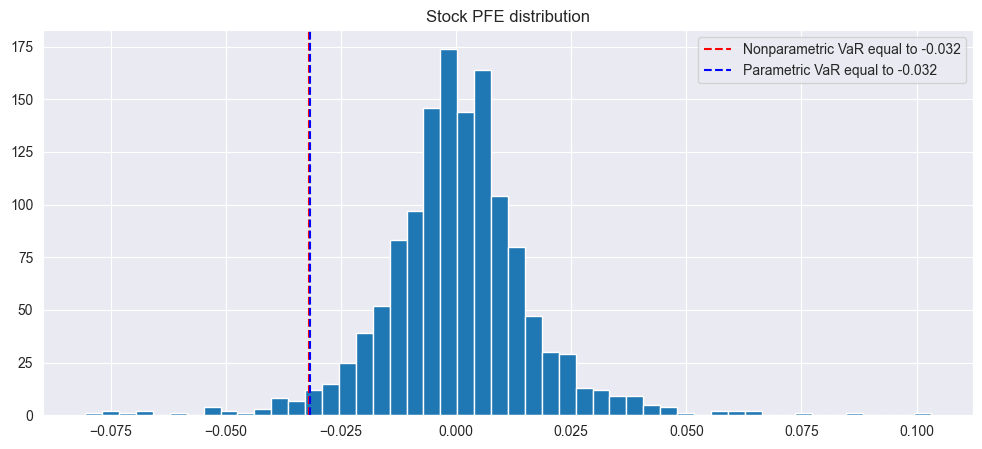

--------------------------------------------------


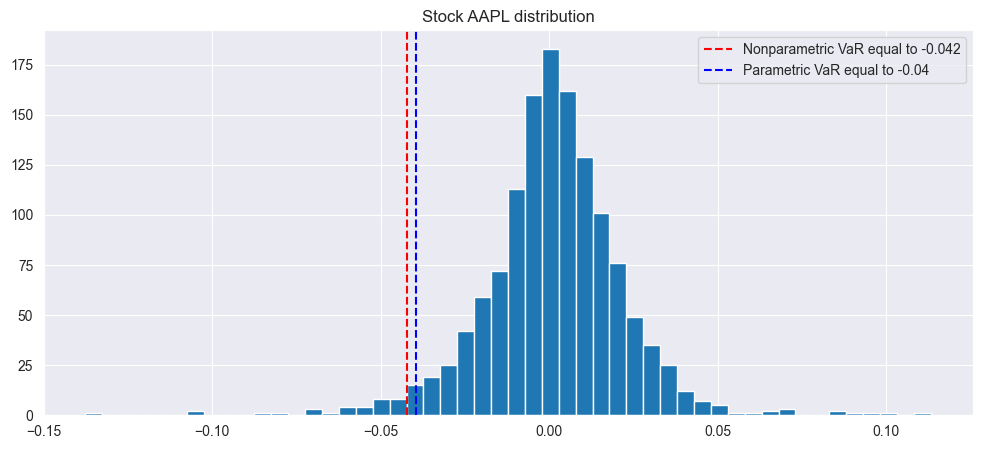

--------------------------------------------------


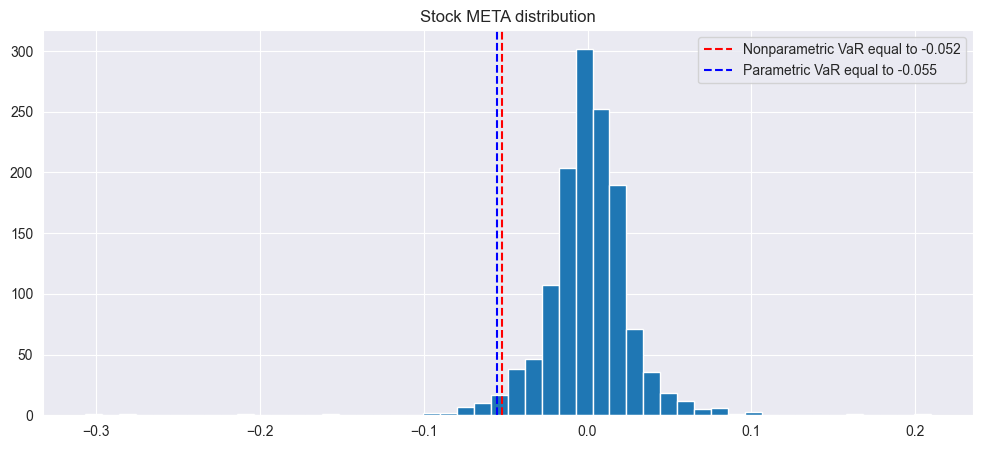

--------------------------------------------------


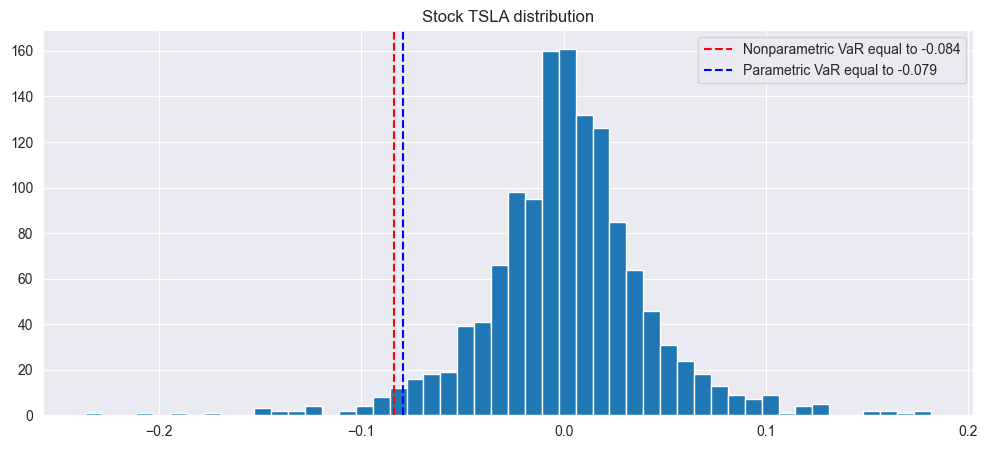

--------------------------------------------------


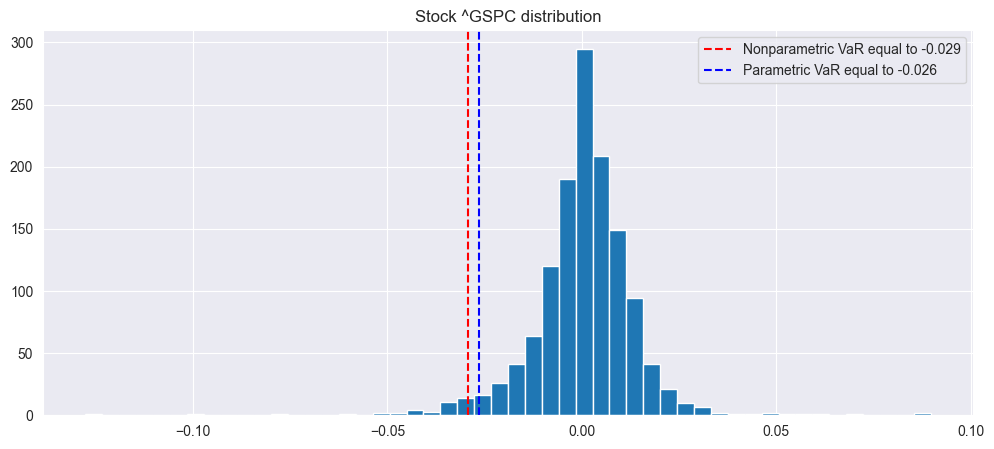

--------------------------------------------------


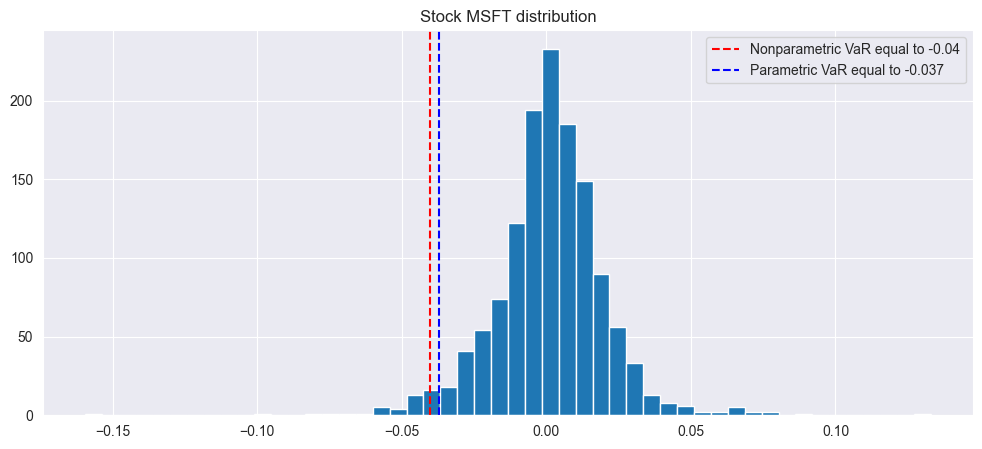

--------------------------------------------------


In [56]:
for ticker in tickers:
  df_log[ticker].hist(bins=50,figsize=(12,5));
  plt.title(f"Stock {ticker} distribution");
  for var_metric, color_plot in [("Nonparametric VaR",'red'),("Parametric VaR","blue")]:
    value_to_plot = df_comp_vars.loc[ticker,var_metric]#.iloc[0]
    plt.axvline(-value_to_plot, label=f"{var_metric} equal to {-round(value_to_plot, 3)}", linestyle='--', color=color_plot);
    plt.legend();
  plt.show();
  print(50*"-")

In [57]:
def skewness(r):
  r_minus_mean = r-r.mean()
  sigma_r = r.std(ddof=0)
  exp = (r_minus_mean**3).mean()
  return exp/sigma_r**3

def kurtosis(r):
  r_minus_mean = r-r.mean()
  sigma_r = r.std(ddof=0)
  exp = (r_minus_mean**4).mean()
  return exp/sigma_r**4


## Cornish-Fisher Modification

The Cornish–Fisher expansion is an asymptotic expansion used to approximate the quantiles of a probability distribution based on its cumulants.

The z-score tells us how many standard deviations away from the mean we need to go to find the VaR. If the returns arent normal, we know that z-score will give us an inaccurate number. The basic idea is that since we can observe the skewness and kurtosis of the data, we can adjust the z-score up or down to come up with a modifed z-score. e.g. intuitively, all other things being equal, if the skewness is negative, we'll decrease the z-score further down, and if the skewness is positive, we'll push it up.

The adjusted z-score which we'll call $z_{cornishfisher}$ given by:

$$ z_{cornishfisher} = z +\frac{1}{6}(z^2-1)S + \frac{1}{24}(z^3-3z)(K-3)-\frac{1}{36}(2z^3-5z)S^2 $$


We can modify the previous function by adding a "modified" parameter with a default value of `True` as follows. If `True` then the following piece of code is executed, which modifes `z`:

In [58]:
def parametric_var(
    df:pd.DataFrame, 
    level_confidence:float=95, 
    modified:bool=False
):
  """
  Get parametric var from log-returns pd.DataFrame
  Parameters 
  ----------
  df
  level_confidence
  """
  level = (100-level_confidence) / 100
  z = norm.ppf(level)

  if modified:
    skewness_value = skewness(df)
    kurtosis_value = kurtosis(df)

    z = z + (z**2 - 1)*skewness_value/6 + (z**3 - 3*z)*(kurtosis_value-3)/24 - (2*z**3 - 5*z)*(skewness_value**2)/36

  return -(z*df.std(ddof=0) + df.mean())


parametric_var(df_log, 95, True)

AAPL     0.032566
DIS      0.029233
KO       0.022513
MAT      0.041966
META     0.044812
MSFT     0.029827
NVDA     0.054065
PFE      0.024648
TSLA     0.065203
^GSPC    0.021412
dtype: float64

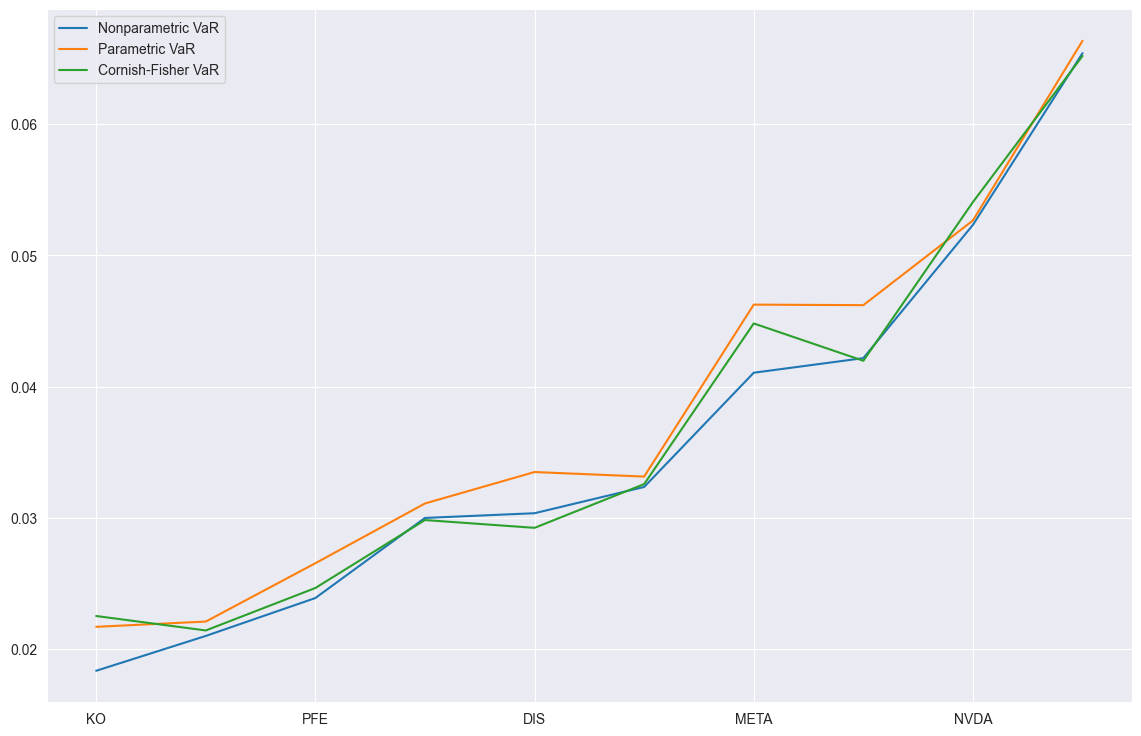

In [59]:
df_comp_vars = pd.concat(
    [
        historic_var(df_log, 95),
        parametric_var(df_log, 95),
        parametric_var(df_log, 95, True),
        
    ],axis=1
).rename(
    columns={
        0:'Nonparametric VaR',
        1:'Parametric VaR',
        2:"Cornish-Fisher VaR"
    }
)

df_comp_vars.plot(figsize=(14,9));

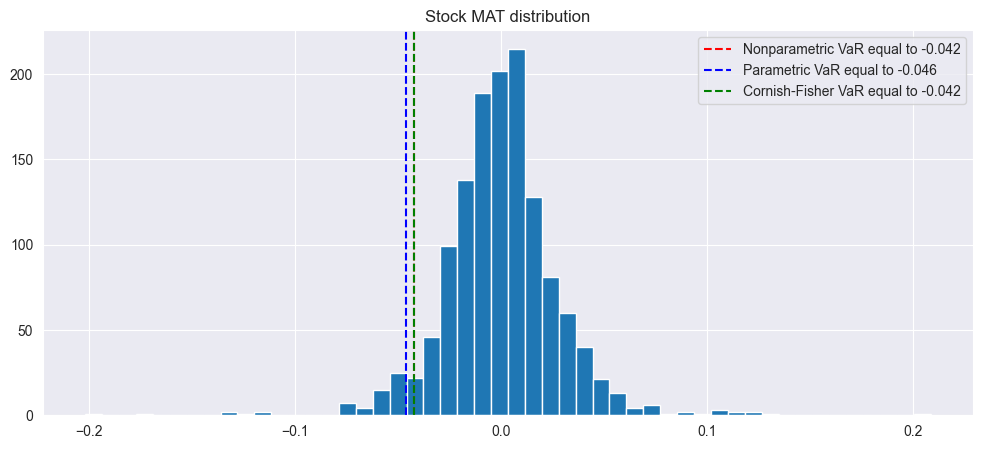

--------------------------------------------------


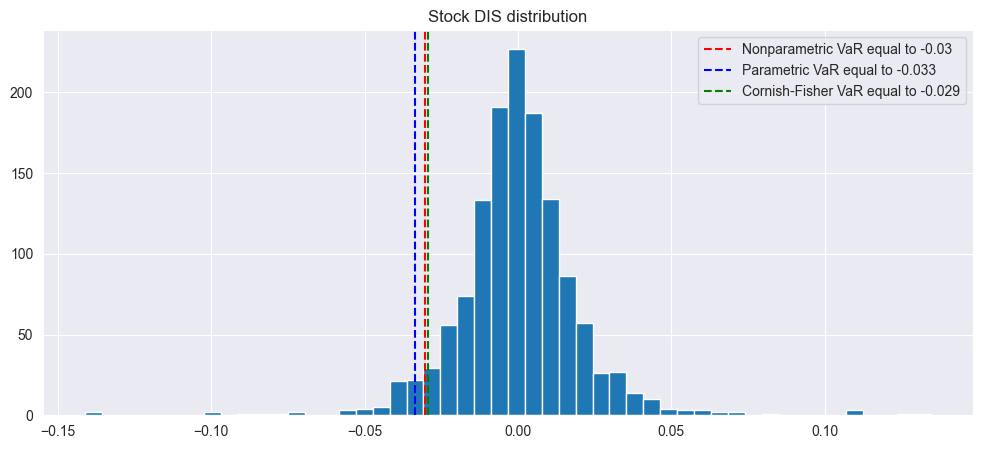

--------------------------------------------------


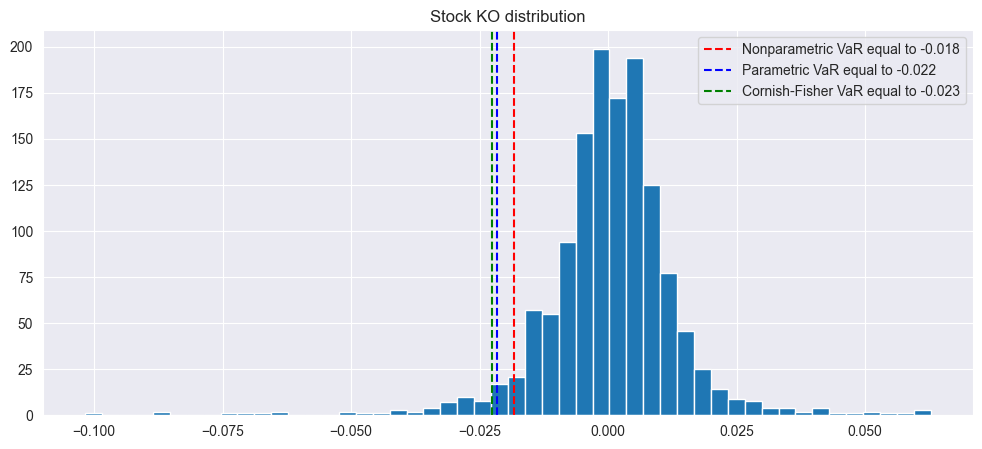

--------------------------------------------------


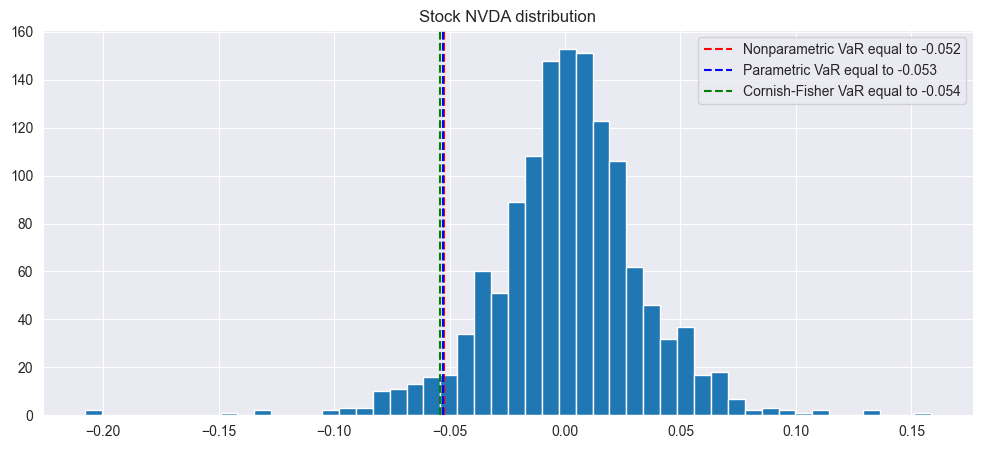

--------------------------------------------------


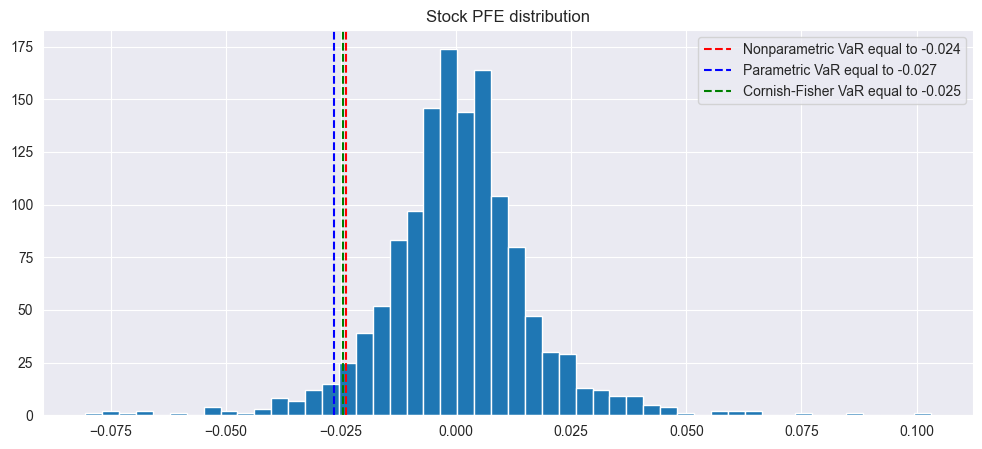

--------------------------------------------------


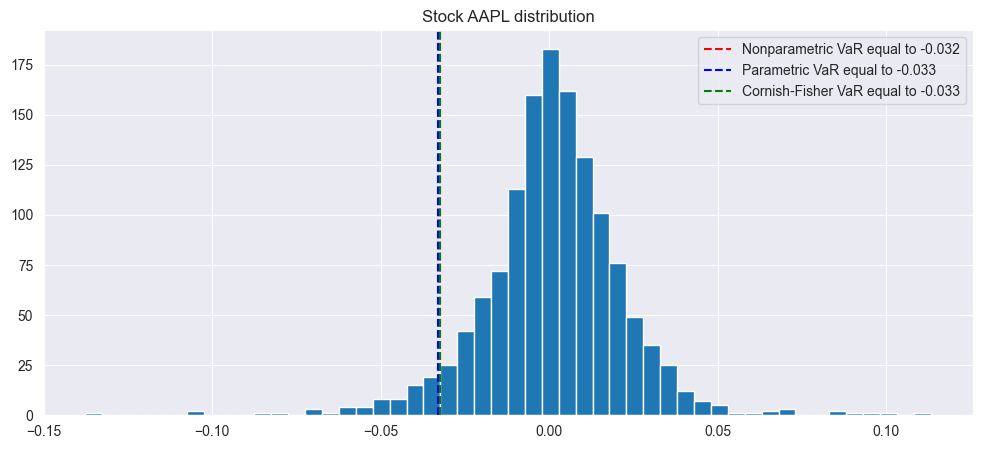

--------------------------------------------------


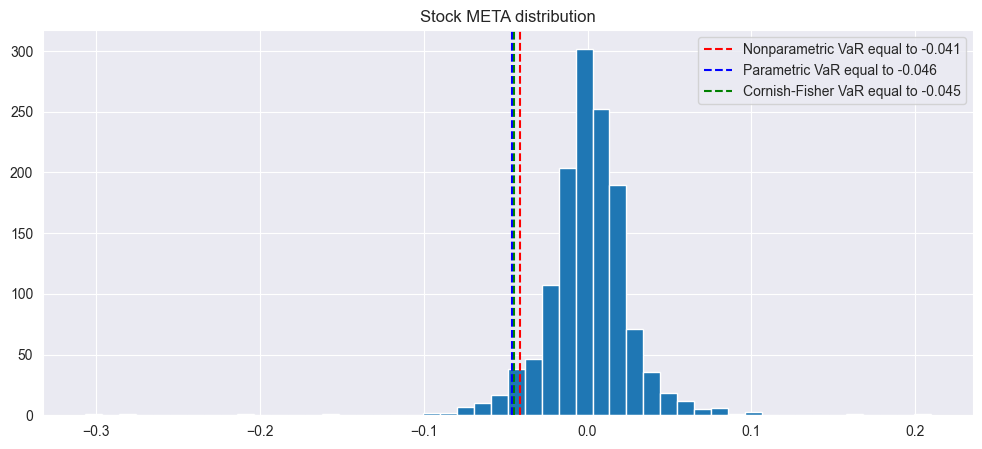

--------------------------------------------------


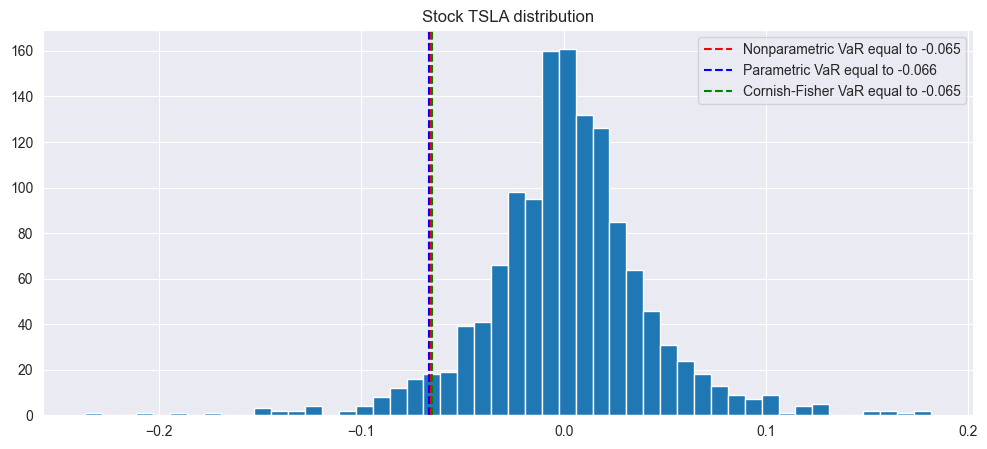

--------------------------------------------------


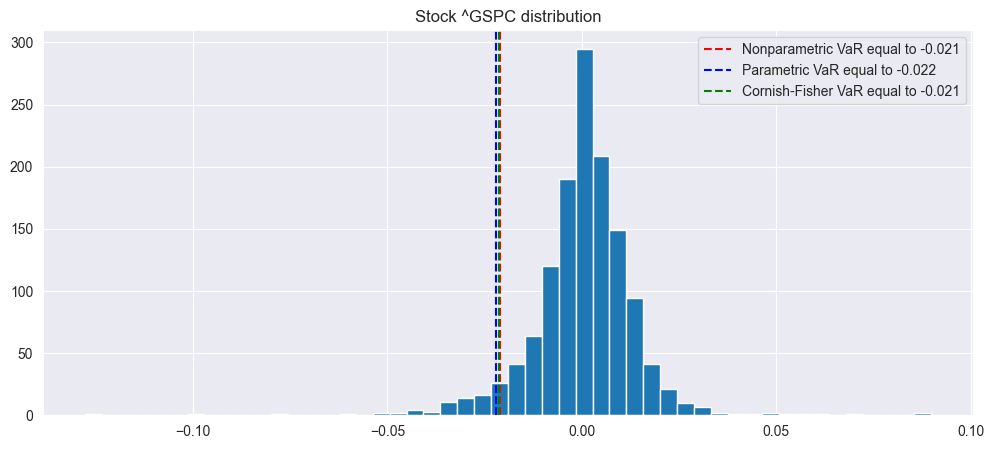

--------------------------------------------------


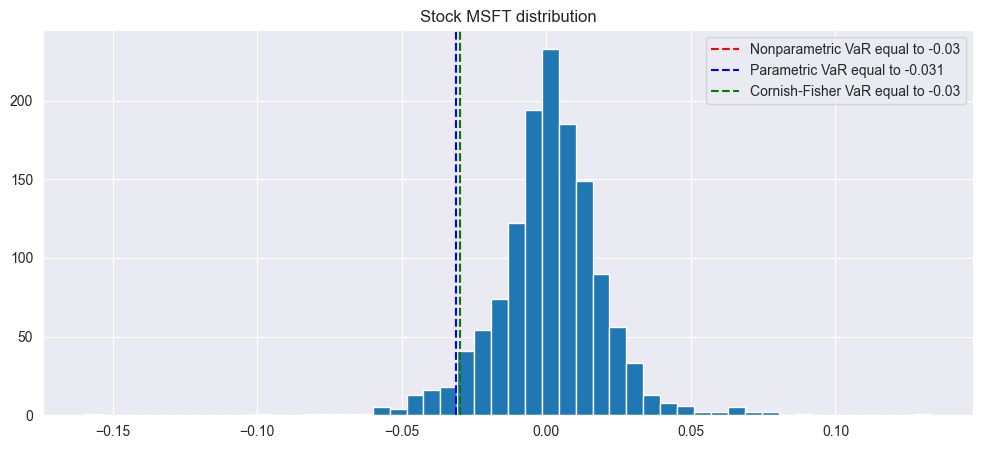

--------------------------------------------------


In [60]:
for ticker in tickers:
  df_log[ticker].hist(bins=50,figsize=(12,5));
  plt.title(f"Stock {ticker} distribution");
  for var_metric, color_plot in [("Nonparametric VaR",'red'),("Parametric VaR","blue"), ("Cornish-Fisher VaR","green")]:
    value_to_plot = df_comp_vars.loc[ticker,var_metric]#.iloc[0]
    plt.axvline(-value_to_plot, label=f"{var_metric} equal to {-round(value_to_plot, 3)}", linestyle='--', color=color_plot);
    plt.legend();
  plt.show();
  print(50*"-")